<a href="https://colab.research.google.com/github/mcloudoul/Olist-E-Commerce-Dashboard/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Sri Hartati Setia Ningrum
- **Email:** 	CDCC200D6X1030@student.devacademy.id
- **ID Dicoding:** CDCC200D6X1030

## Menentukan Pertanyaan Bisnis

- Bagaimana tren total revenue dan jumlah order per bulan selama periode 2016–2018, serta apakah terdapat pola musiman yang dapat dimanfaatkan untuk strategi penjualan?

- Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM), dan kelompok pelanggan mana yang memberikan kontribusi terbesar terhadap total revenue selama periode 2016–2018?

- Kategori produk apa yang memberikan kontribusi terbesar terhadap total revenue, dan bagaimana distribusi kontribusi tersebut selama periode 2016–2018?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import os
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from google.colab import drive
from google.colab import files
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

In [ ]:
# IMPORT DATA

drive.mount('/content/drive')

drive_folder_path = '/content/drive/MyDrive/Proyek Fundamental Analisis Data'

# LOAD TABEL CUSTOMERS
customers_df = pd.read_csv(f'{drive_folder_path}/customers_dataset.csv')

# LOAD TABEL ORDERS
orders_df = pd.read_csv(f'{drive_folder_path}/orders_dataset.csv')

# LOAD TABEL ORDER ITEMS
order_items_df = pd.read_csv(f'{drive_folder_path}/order_items_dataset.csv')

# LOAD TABEL PRODUCTS
products_df = pd.read_csv(f'{drive_folder_path}/products_dataset.csv')

# LOAD TABEL PRODUCT CATEGORY (TRANSLATION)
products_category_df = pd.read_csv(f'{drive_folder_path}/product_category_name_translation.csv')

Mounted at /content/drive


In [ ]:
# LOAD TABEL CUSTOMERS
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
# LOAD TABEL ORDERS
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# LOAD TABEL ORDER ITEMS
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
# LOAD TABEL PRODUCTS
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
# LOAD TABEL PRODUCTS CATEGORY
products_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**

- Dataset yang telah dimuat terdiri dari lima tabel utama yang berkaitan dengan e-commerce, yaitu `customers_df`, `orders_df`, `order_items_df`, `products_df`, dan `products_category_df`.
- Setiap tabel memiliki informasi unik (misalnya, detail pelanggan, informasi pesanan, item yang dibeli, deskripsi produk, metode pembayaran, dan ulasan pelanggan).
- Keberadaan berbagai ID (`customer_id`, `order_id`, `product_id`, dll.) menunjukkan potensi untuk menggabungkan tabel-tabel ini, memungkinkan analisis komprehensif dari seluruh siklus transaksi e-commerce, mulai dari pembelian hingga ulasan pelanggan.
- Dataset `product_category_name_translation.csv` dimasukkan karena pada dataset asli `products_dataset.csv` menggunakan bahasa Portugis, sehingga perlu menambahkan data `product_category_name_translation.csv` untuk memudahkan interpretasi nantinya.

### Assessing Data

**Menilai Data customers_df**

In [ ]:
# Informasi Data
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
# Deteksi Missing Value
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
# Deteksi Duplikasi Data
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


**Hasil Penilaian customers_df**

- Dari hasil penilaian data `customers_df` di atas, didapatkan bahwa jumlah data pada `customers_df` telah lengkap atau dengan kata lain tidak ada *missing value* di dalamnya.
- Hasil tersebut kemudian dibuktikan kembali menggunakan `isna().sum()`.
- Selain itu, didapatkan hasil bahwa tidak ada data yang terduplikasi di `customers_df`.

**Menilai Data orders_df**

In [ ]:
# Informasi Data
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
# Deteksi Missing Value
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
# Deteksi Duplikasi Data
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


**Hasil Penilaian orders_df**

- Dari hasil penilaian data `orders_df` di atas, didapatkan bahwa terdapat beberapa kolom yang memiliki data tidak lengkap, hal tersebut menandakan terdapat *missing value* di dalamnya.
- Hasil tersebut kemudian dibuktikan dengan `isna().sum()`, dimana terdapat *missing value* untuk beberapa kolom.
- Dari hasil di atas juga didapatkan bahwa terdapat masalah tipe data pada beberapa kolom di `orders_df`, yaitu kolom `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, dan `order_estimated_delivery_date`. Kelima kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object.
- Dari hasil di atas, tidak ada data yang terduplikasi di `orders_df`.


**Menilai Data order_items_df**

In [ ]:
# Informasi Data
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
# Deteksi Missing Value
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
# Deteksi Duplikasi Data
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
# Deskripsi Data
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Hasil Penilaian order_items_df**

- Dari hasil penilaian `order_items_df` di atas, didapatkan bahwa data sudah lengkap yang menandakan tidak ada *missing value* di `order_items_df`. Hasil ini kemudian dibuktikan kembali menggunakan `isna().sum()`
- Akan tetapi, terdapat masalah tipe data untuk kolom `shipping_limit_date`, dimana kolom tersebut seharusnya direpresentasikan sebagai datetime bukan object.
- Dari hasil di atas, terlihat bahwa tidak ada data yang terduplikasi di `order_items_df`
- Terdapat variasi harga yang cukup besar antara nilai minimum dan maksimum.

**Menilai Data products_df**

In [ ]:
# Informasi Data
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
# Deteksi Missing Value
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
# Deteksi Duplikasi Data
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
# Deskripsi Data
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Hasil Penilaian products_df**

- Dari hasil penilaian data `products_df` di atas, didapatkan bahwa terdapat beberapa kolom yang memiliki data tidak lengkap, hal tersebut menandakan terdapat *missing value* di dalamnya.
- Hasil tersebut kemudian dibuktikan dengan `isna().sum()`, dimana terdapat *missing value* pada hampir semua kolom.
- Kemudian, dari hasil di atas terlihat bahwa tidak ada data yang terduplikasi di `products_df`

**Menilai Data products_category_df**

In [ ]:
# Informasi Data
products_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [ ]:
# Deteksi Missing Value
products_category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [ ]:
# Deteksi Duplikasi Data
print("Jumlah duplikasi: ", products_category_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Secara umum, kualitas data cukup baik dan tidak ditemukan adanya duplikasi pada seluruh dataset.
- Dataset `customers_df`, `order_items_df`, `products_category_df` tidak memiliki missing values sehingga dapat langsung digunakan.
- Dataset `orders_df` dan `products_df` masih memiliki missing values pada beberapa kolom yang perlu ditangani lebih lanjut.
- Terdapat ketidaksesuaian tipe data pada beberapa kolom bertipe waktu (timestamp) yang masih berbentuk `object` dan perlu dikonversi menjadi `datetime`.
- Tidak semua dataset memerlukan analisis lanjutan seperti outlier, karena disesuaikan dengan karakteristik masing-masing data.
- Diperlukan tahap data cleaning untuk menangani missing values dan memperbaiki tipe data sebelum dilakukan analisis lebih lanjut.

### Cleaning Data

**Membersihkan Data orders_df**

In [ ]:
# Drop kolom yang tidak relevan
orders_df = orders_df.drop(columns=[
    'order_status',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# Cek Kembali
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   order_id                  99441 non-null  object
 1   customer_id               99441 non-null  object
 2   order_purchase_timestamp  99441 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB


In [ ]:
# Memperbaiki Tipe Data
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

# Cek Kembali
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  99441 non-null  object        
 1   customer_id               99441 non-null  object        
 2   order_purchase_timestamp  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 2.3+ MB


**Membersihkan Data order_items_df**

In [ ]:
# Drop kolom yang tidak relevan
order_items_df = order_items_df.drop(columns=[
    'order_item_id',
    'seller_id',
    'shipping_limit_date',
    'freight_value'
])

# Cek Kembali
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   order_id    112650 non-null  object 
 1   product_id  112650 non-null  object 
 2   price       112650 non-null  float64
dtypes: float64(1), object(2)
memory usage: 2.6+ MB


**Membersihkan Data products_df**

In [ ]:
# Drop kolom yang tidak relevan
products_df = products_df.drop(columns=[
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
])

# Cek Kembali
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   product_id             32951 non-null  object
 1   product_category_name  32341 non-null  object
dtypes: object(2)
memory usage: 515.0+ KB


In [ ]:
# Menangani Missing Value
products_df['product_category_name'] = products_df['product_category_name'].fillna('Unknown')

# Cek Kembali
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   product_id             32951 non-null  object
 1   product_category_name  32951 non-null  object
dtypes: object(2)
memory usage: 515.0+ KB


**Insight:**
- Pada dataset `orders_df`, dilakukan seleksi kolom dengan menghapus kolom yang tidak relevan terhadap analisis, yaitu `order_status`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, dan `order_estimated_delivery_date`. Kolom seperti status order dan informasi pengiriman tidak digunakan karena analisis dalam proyek ini difokuskan pada pola transaksi dan revenue, bukan pada performa pengiriman atau status pesanan. Oleh karena itu, kolom tersebut dihapus untuk menyederhanakan dataset dan meningkatkan efisiensi pengolahan data. Selain itu, dilakukan konversi tipe data pada kolom yang berkaitan dengan waktu, seperti `order_purchase_timestamp`, dari tipe `object` menjadi `datetime`. Hal ini dilakukan agar data dapat digunakan dalam analisis berbasis waktu secara lebih akurat.

- Pada dataset `order_items_df`, dilakukan seleksi kolom dengan mempertahankan hanya kolom yang relevan, yaitu `order_id`, `product_id`, dan `price`. Kolom lain seperti `seller_id`, `shipping_limit_date`, `freight_value`, dan `order_item_id` tidak digunakan karena tidak berkaitan langsung dengan kebutuhan analisis yang berfokus pada nilai transaksi (revenue) dan relasi antara order, customer, dan produk. Variabel tersebut lebih relevan untuk analisis logistik atau performa penjual, yang berada di luar scope proyek ini.

- Pada dataset `products_df`, dilakukan seleksi kolom dengan hanya menggunakan `product_id` dan `product_category_name` yang diperlukan untuk analisis kategori produk. Selain itu, ditemukan adanya missing values pada kolom `product_category_name`. Untuk mengatasi hal tersebut, nilai yang kosong diisi dengan label "Unknown". Pengisian missing values dengan label "Unknown" dilakukan agar data tetap dapat digunakan dalam analisis tanpa mengurangi jumlah observasi. Namun, kategori "Unknown" ini perlu diperhatikan dalam interpretasi hasil karena dapat memengaruhi distribusi kontribusi kategori produk terhadap revenue.

## Exploratory Data Analysis (EDA)

In [ ]:
# Setup EDA

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

print("Setup EDA selesai!")
print(f"Data orders: {orders_df.shape}")
print(f"Data order_items: {order_items_df.shape}")
print(f"Data products: {products_df.shape}")

Setup EDA selesai!
Data orders: (99441, 3)
Data order_items: (112650, 3)
Data products: (32951, 2)


### EDA UNIVARIATE (Histogram, Boxplot, Skewness, Kurtosis)

Data untuk EDA: (112650, 10)
Periode: 2016-09-04 21:15:19 - 2018-09-03 09:06:57
Range harga: $0.85 - $6735.00


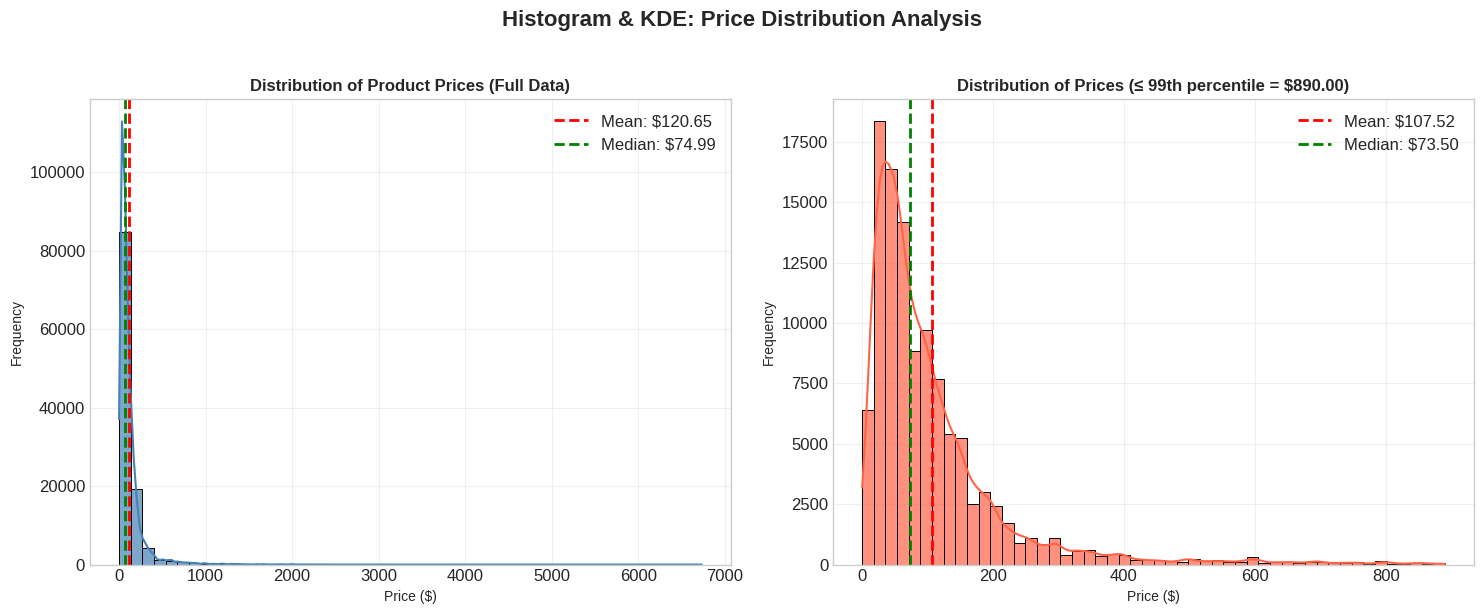


BOXPLOT STATISTICS
Q1 (25th percentile): $39.90
Q3 (75th percentile): $134.90
IQR (Interquartile Range): $95.00
Lower bound (Q1 - 1.5*IQR): $-102.60
Upper bound (Q3 + 1.5*IQR): $277.40
Jumlah outlier: 8427 items


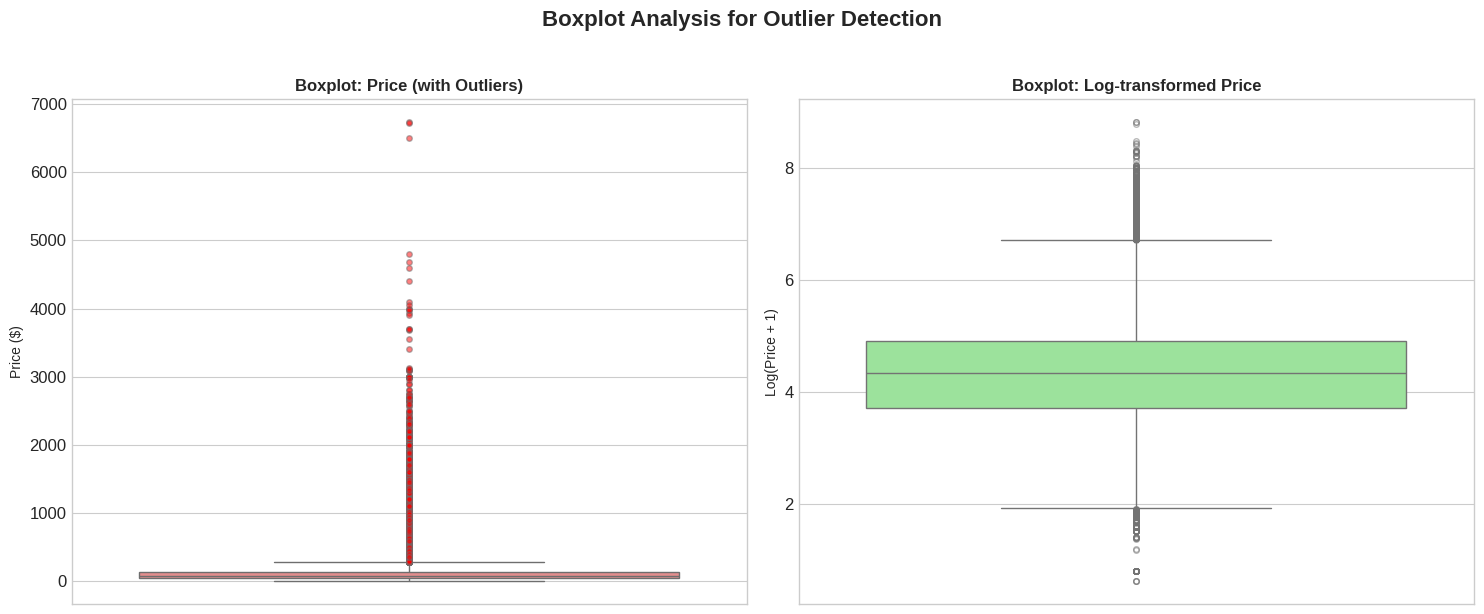


SKEWNESS & KURTOSIS ANALYSIS

Variable: PRICE
  Skewness: 7.9232 → Right-skewed (positively skewed) - longer right tail
  Kurtosis: 120.8283 → Leptokurtic (heavy-tailed) - more outliers than normal

Interpretasi: Data harga produk memiliki distribusi yang sangat right-skewed
  (banyak produk dengan harga rendah, sedikit produk premium dengan harga tinggi)


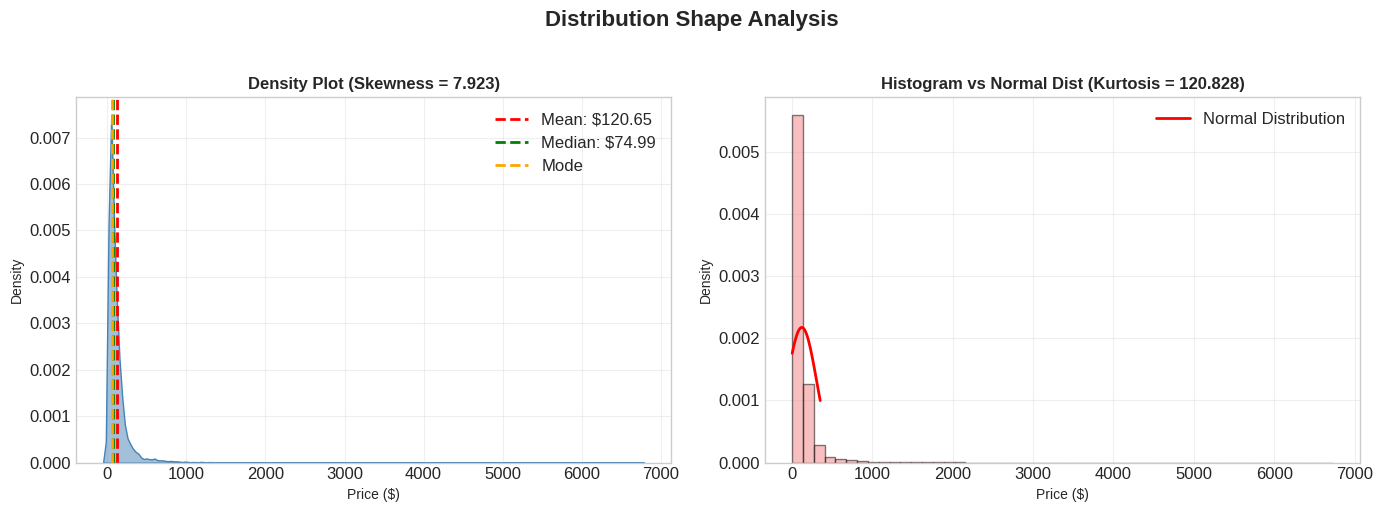

In [ ]:
# Buat dataframe gabungan untuk analisis

# Merge order_items dengan orders untuk mendapatkan timestamp
df_eda = order_items_df.merge(orders_df, on='order_id', how='inner')
# Merge dengan products untuk kategori
df_eda = df_eda.merge(products_df, on='product_id', how='left')
# Merge dengan category translation
df_eda = df_eda.merge(products_category_df, on='product_category_name', how='left')

# Variabel numerik yang akan dianalisis
numeric_vars = ['price']  # Dari order_items_df

# Tambahkan kolom bulan/tahun untuk analisis waktu
df_eda['order_year'] = df_eda['order_purchase_timestamp'].dt.year
df_eda['order_month'] = df_eda['order_purchase_timestamp'].dt.month
df_eda['order_year_month'] = df_eda['order_purchase_timestamp'].dt.to_period('M')

print(f"Data untuk EDA: {df_eda.shape}")
print(f"Periode: {df_eda['order_purchase_timestamp'].min()} - {df_eda['order_purchase_timestamp'].max()}")
print(f"Range harga: ${df_eda['price'].min():.2f} - ${df_eda['price'].max():.2f}")

# ========== 1. HISTOGRAM + KDE ==========
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram dengan KDE (full data)
sns.histplot(data=df_eda, x='price', kde=True, ax=axes[0],
             color='steelblue', edgecolor='black', alpha=0.7, bins=50)
mean_val = df_eda['price'].mean()
median_val = df_eda['price'].median()
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:.2f}')
axes[0].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_val:.2f}')
axes[0].set_title('Distribution of Product Prices (Full Data)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram dengan KDE (filtered, exclude extreme outliers > 99th percentile)
upper_limit = df_eda['price'].quantile(0.99)
filtered_prices = df_eda[df_eda['price'] <= upper_limit]['price']
sns.histplot(data=filtered_prices, kde=True, ax=axes[1],
             color='tomato', edgecolor='black', alpha=0.7, bins=50)
mean_filt = filtered_prices.mean()
median_filt = filtered_prices.median()
axes[1].axvline(mean_filt, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_filt:.2f}')
axes[1].axvline(median_filt, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_filt:.2f}')
axes[1].set_title(f'Distribution of Prices (≤ 99th percentile = ${upper_limit:.2f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price ($)', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Histogram & KDE: Price Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== 2. BOXPLOT UNTUK OUTLIER DETECTION ==========
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot standar
sns.boxplot(y=df_eda['price'], ax=axes[0], color='lightcoral',
            flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5, 'markerfacecolor': 'red'})
axes[0].set_title('Boxplot: Price (with Outliers)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=10)

# Boxplot after log transformation untuk melihat distribusi lebih baik
df_eda['log_price'] = np.log1p(df_eda['price'])
sns.boxplot(y=df_eda['log_price'], ax=axes[1], color='lightgreen',
            flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5})
axes[1].set_title('Boxplot: Log-transformed Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log(Price + 1)', fontsize=10)

# Tambahkan statistik IQR
q1 = df_eda['price'].quantile(0.25)
q3 = df_eda['price'].quantile(0.75)
iqr = q3 - q1
print("\n" + "="*60)
print("BOXPLOT STATISTICS")
print("="*60)
print(f"Q1 (25th percentile): ${q1:.2f}")
print(f"Q3 (75th percentile): ${q3:.2f}")
print(f"IQR (Interquartile Range): ${iqr:.2f}")
print(f"Lower bound (Q1 - 1.5*IQR): ${q1 - 1.5*iqr:.2f}")
print(f"Upper bound (Q3 + 1.5*IQR): ${q3 + 1.5*iqr:.2f}")
print(f"Jumlah outlier: {(df_eda['price'] > q3 + 1.5*iqr).sum()} items")

plt.suptitle('Boxplot Analysis for Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== 3. SKEWNESS & KURTOSIS ANALYSIS ==========
print("\n" + "="*60)
print("SKEWNESS & KURTOSIS ANALYSIS")
print("="*60)

skew_val = df_eda['price'].skew()
kurt_val = df_eda['price'].kurtosis()

# Interpretasi skewness
if skew_val > 0.5:
    skew_desc = "Right-skewed (positively skewed) - longer right tail"
elif skew_val < -0.5:
    skew_desc = "Left-skewed (negatively skewed) - longer left tail"
else:
    skew_desc = "Approximately symmetric"

# Interpretasi kurtosis
if kurt_val > 3:
    kurt_desc = "Leptokurtic (heavy-tailed) - more outliers than normal"
elif kurt_val < 3:
    kurt_desc = "Platykurtic (light-tailed) - fewer outliers than normal"
else:
    kurt_desc = "Mesokurtic (normal tail)"

print(f"\nVariable: PRICE")
print(f"  Skewness: {skew_val:.4f} \u2192 {skew_desc}")
print(f"  Kurtosis: {kurt_val:.4f} \u2192 {kurt_desc}")
print(f"\nInterpretasi: Data harga produk memiliki distribusi yang sangat right-skewed")
print(f"  (banyak produk dengan harga rendah, sedikit produk premium dengan harga tinggi)")

# Visualisasi skewness & kurtosis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Visualisasi skewness dengan density plot
sns.kdeplot(data=df_eda, x='price', ax=ax1, fill=True, color='steelblue', alpha=0.5)
ax1.axvline(df_eda['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df_eda["price"].mean():.2f}')
ax1.axvline(df_eda['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df_eda["price"].median():.2f}')
ax1.axvline(df_eda['price'].mode()[0] if len(df_eda['price'].mode()) > 0 else 0,
            color='orange', linestyle='--', linewidth=2, label=f'Mode')
ax1.set_title(f'Density Plot (Skewness = {skew_val:.3f})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Price ($)', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Visualisasi kurtosis dengan histogram + theoretical normal
from scipy.stats import norm
mu, std = df_eda['price'].mean(), df_eda['price'].std()
x = np.linspace(df_eda['price'].min(), df_eda['price'].quantile(0.95), 100)
ax2.hist(df_eda['price'], bins=50, density=True, alpha=0.5, color='lightcoral', edgecolor='black')
ax2.plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2, label='Normal Distribution')
ax2.set_title(f'Histogram vs Normal Dist (Kurtosis = {kurt_val:.3f})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Price ($)', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Distribution Shape Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:**

**Histogram & KDE Analysis**

Distribusi harga produk menunjukkan pola yang sangat tidak simetris (positively skewed), di mana mayoritas produk berada pada rentang harga rendah, sementara hanya sebagian kecil produk memiliki harga yang sangat tinggi. Hal ini terlihat dari perbedaan yang cukup signifikan antara nilai mean dan median, di mana mean cenderung lebih besar akibat pengaruh nilai ekstrem (outliers).

Visualisasi histogram yang difilter hingga persentil ke-99 memberikan gambaran yang lebih representatif terhadap distribusi mayoritas data. Tanpa adanya nilai ekstrem, distribusi terlihat lebih terpusat, namun tetap menunjukkan kecenderungan skew ke kanan.

Temuan ini mengindikasikan bahwa struktur harga produk dalam dataset tidak merata dan cenderung didominasi oleh produk dengan harga rendah hingga menengah. Sementara itu, produk dengan harga tinggi hanya menyumbang sebagian kecil observasi, namun berpotensi memiliki kontribusi signifikan terhadap total pendapatan.

Implikasinya, analisis berbasis rata-rata (mean) perlu dilakukan dengan hati-hati karena dapat terdistorsi oleh nilai ekstrem. Oleh karena itu, penggunaan median atau pendekatan segmentasi harga menjadi lebih relevan untuk menggambarkan karakteristik data secara akurat.

---

**Boxplot & Outlier Detection**

Hasil visualisasi boxplot menunjukkan adanya sejumlah besar outlier pada distribusi harga produk, khususnya pada batas atas (upper bound). Nilai outlier ini berada jauh di atas rentang interquartile (IQR), yang mengindikasikan keberadaan produk dengan harga premium atau sangat tinggi dibandingkan mayoritas produk lainnya.

Perhitungan IQR memperkuat temuan ini, di mana selisih antara kuartil ketiga (Q3) dan kuartil pertama (Q1) relatif kecil dibandingkan dengan rentang maksimum data. Hal ini menunjukkan bahwa sebagian besar data terkonsentrasi dalam rentang yang sempit, sementara nilai ekstrem berada jauh di luar distribusi utama.

Transformasi logaritmik (log transformation) pada harga berhasil memperbaiki visualisasi distribusi, membuat pola menjadi lebih simetris dan lebih mudah dianalisis. Hal ini mengindikasikan bahwa distribusi awal bersifat highly skewed dan memerlukan transformasi untuk analisis statistik lanjutan.

Implikasi dari temuan ini adalah bahwa keberadaan outlier bukan sekadar noise, melainkan kemungkinan mencerminkan variasi harga produk yang nyata, seperti perbedaan kategori produk atau strategi pricing. Oleh karena itu, outlier tidak serta-merta dihapus, melainkan perlu dipertimbangkan dalam konteks analisis bisnis.

---

**Skewness & Kurtosis Analysis**

Nilai skewness yang positif dan cukup tinggi menunjukkan bahwa distribusi harga memiliki ekor panjang di sisi kanan (right tail), yang mengindikasikan dominasi produk dengan harga rendah dan keberadaan sejumlah kecil produk dengan harga tinggi.

Sementara itu, nilai kurtosis yang lebih tinggi dari distribusi normal (leptokurtic) menunjukkan bahwa data memiliki ekor yang lebih berat (heavy-tailed), sehingga lebih banyak mengandung outlier dibandingkan distribusi normal.

Kombinasi antara skewness positif dan kurtosis tinggi mengindikasikan bahwa distribusi harga tidak hanya tidak simetris, tetapi juga memiliki konsentrasi nilai ekstrem yang signifikan. Hal ini diperkuat oleh perbedaan posisi antara mean, median, dan mode dalam visualisasi density plot.

Perbandingan histogram dengan distribusi normal juga menunjukkan deviasi yang jelas, di mana data aktual tidak mengikuti pola distribusi Gaussian. Hal ini mengindikasikan bahwa asumsi normalitas tidak terpenuhi.

Implikasinya, metode analisis yang mengasumsikan distribusi normal (seperti beberapa uji parametrik) mungkin kurang sesuai untuk data ini. Oleh karena itu, pendekatan non-parametrik atau transformasi data menjadi lebih relevan untuk digunakan dalam analisis lanjutan.

---

**Kesimpulan EDA Univariate**

Secara keseluruhan, distribusi harga produk dalam dataset menunjukkan karakteristik sebagai berikut:
- Tidak simetris (right-skewed)
- Memiliki banyak outlier pada nilai tinggi
- Tidak berdistribusi normal
- Didominasi oleh produk dengan harga rendah

Karakteristik ini menjadi dasar penting dalam memahami struktur data serta dalam menentukan metode analisis yang tepat pada tahap selanjutnya, khususnya dalam analisis perilaku pelanggan dan kontribusi kategori produk terhadap pendapatan.

### EDA MULTIVARIATE (Violin Plot, Pairplot, Faceted Scatter)

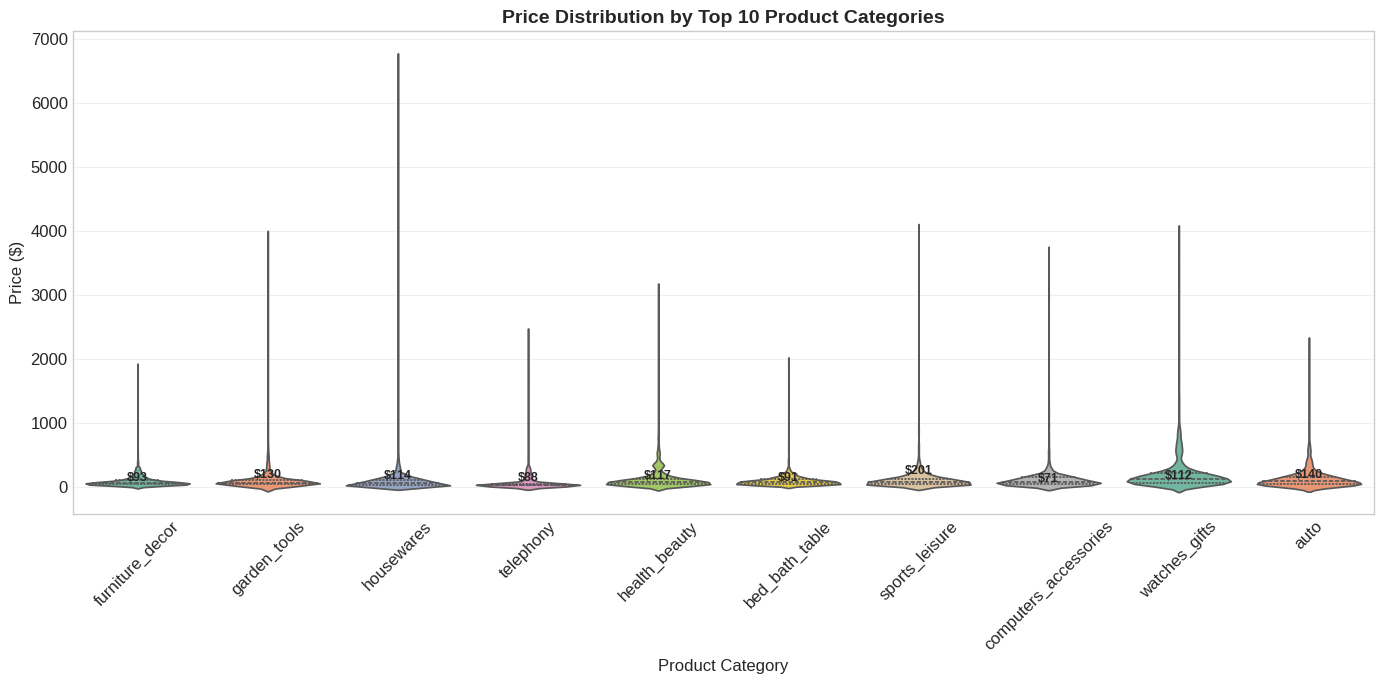

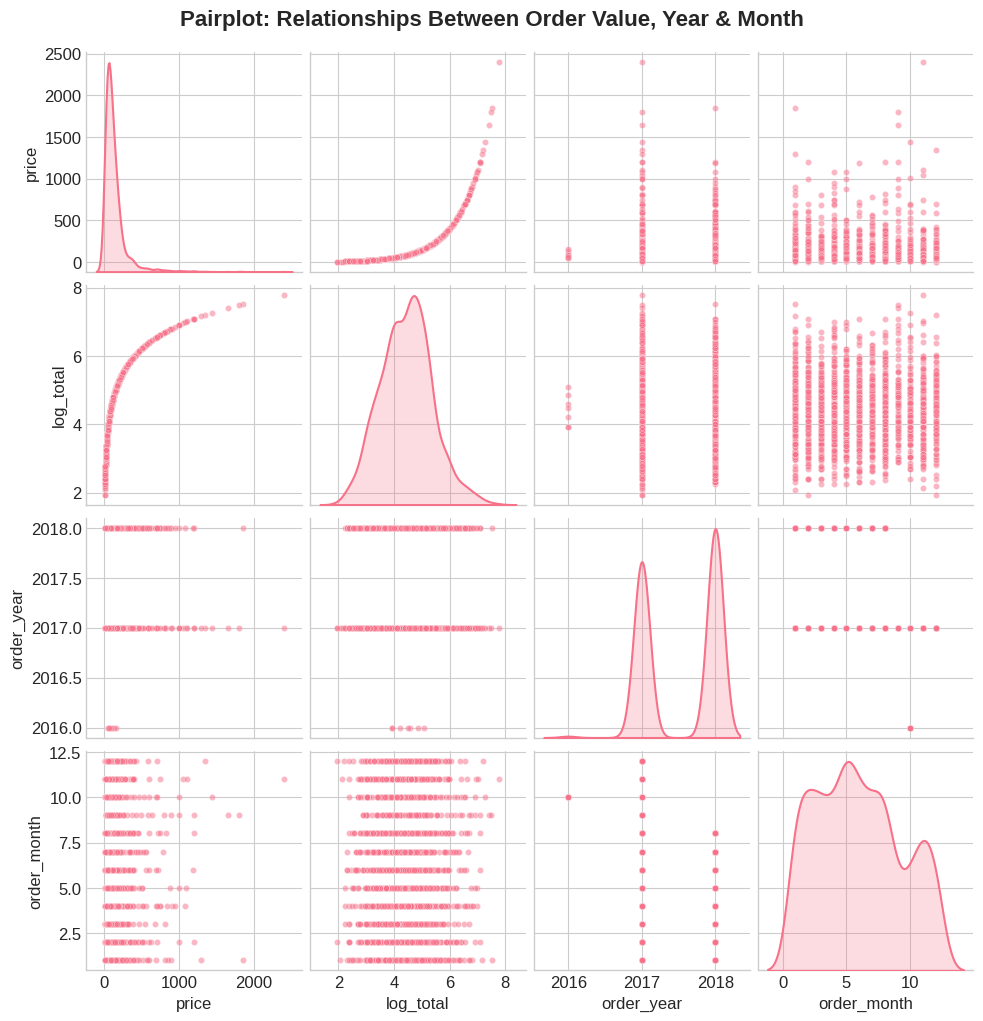

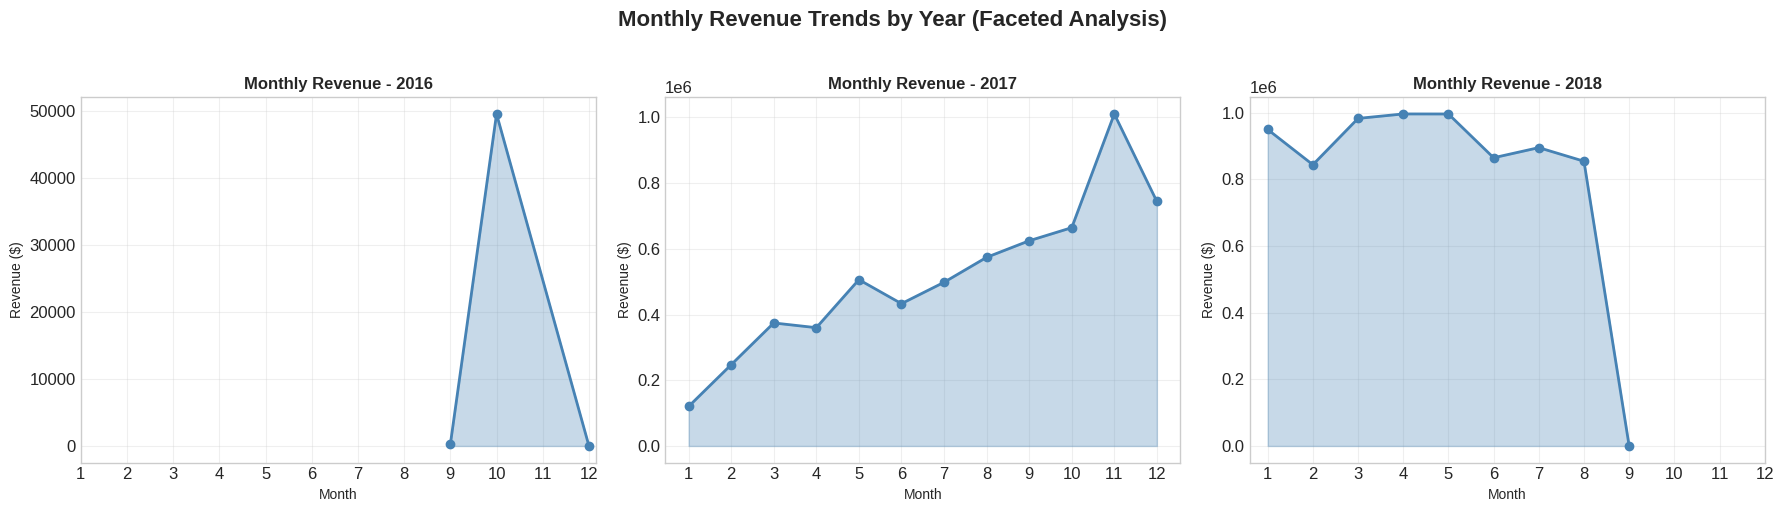

In [ ]:
# ========== 1. VIOLIN PLOT PER KATEGORI ==========
# Ambil top 10 categories untuk visualisasi
top_categories = df_eda['product_category_name_english'].value_counts().head(10).index
df_top_cats = df_eda[df_eda['product_category_name_english'].isin(top_categories)]

fig, ax = plt.subplots(figsize=(14, 7))
sns.violinplot(data=df_top_cats, x='product_category_name_english', y='price',
               palette='Set2', inner='quartile', ax=ax)
ax.set_title('Price Distribution by Top 10 Product Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Tambahkan mean value labels
means = df_top_cats.groupby('product_category_name_english')['price'].mean().round(2)
for i, cat in enumerate(top_categories):
    ax.text(i, means[cat] + 5, f'${means[cat]:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ========== 2. PAIRPLOT UNTUK NUMERIC VARIABLES ==========
# Buat dataframe untuk pairplot (agregasi per order)
order_aggregated = df_eda.groupby('order_id').agg({
    'price': 'sum',  # Total order value
    'order_year': 'first',
    'order_month': 'first'
}).reset_index()
order_aggregated['log_total'] = np.log1p(order_aggregated['price'])

# Pairplot (gunakan sample karena data besar)
df_pairplot = order_aggregated[['price', 'log_total', 'order_year', 'order_month']].dropna()
df_sample = df_pairplot.sample(n=min(2000, len(df_pairplot)), random_state=42)

pairplot_fig = sns.pairplot(df_sample,
                            diag_kind='kde',
                            plot_kws={'alpha': 0.5, 's': 20},
                            diag_kws={'shade': True, 'linewidth': 1.5})
pairplot_fig.fig.suptitle('Pairplot: Relationships Between Order Value, Year & Month',
                          fontsize=16, fontweight='bold', y=1.02)
plt.show()

# ========== 3. FACETED SCATTER PLOT PER TAHUN ==========
# Agregasi monthly revenue
monthly_revenue = df_eda.groupby(['order_year', 'order_month']).agg({
    'price': 'sum'
}).reset_index()
monthly_revenue['year_month_str'] = monthly_revenue['order_month'].astype(str) + '/' + monthly_revenue['order_year'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
years = [2016, 2017, 2018]

for idx, year in enumerate(years):
    year_data = monthly_revenue[monthly_revenue['order_year'] == year]
    axes[idx].plot(year_data['order_month'], year_data['price'], 'o-', linewidth=2, markersize=6, color='steelblue')
    axes[idx].fill_between(year_data['order_month'], year_data['price'], alpha=0.3, color='steelblue')
    axes[idx].set_title(f'Monthly Revenue - {year}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Month', fontsize=10)
    axes[idx].set_ylabel('Revenue ($)', fontsize=10)
    axes[idx].set_xticks(range(1, 13))
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Monthly Revenue Trends by Year (Faceted Analysis)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:**

**Distribusi Harga per Kategori Produk (Violin Plot)**

Visualisasi violin plot menunjukkan bahwa distribusi harga bervariasi secara signifikan antar kategori produk. Beberapa kategori memiliki rentang harga yang lebih luas dan median yang lebih tinggi, sementara kategori lainnya cenderung terkonsentrasi pada harga yang lebih rendah.

Selain itu, terdapat variasi bentuk distribusi dalam masing-masing kategori, yang menunjukkan bahwa tidak semua kategori memiliki pola harga yang seragam. Beberapa kategori menunjukkan distribusi yang lebih simetris, sementara lainnya sangat skewed.

Temuan ini mengindikasikan bahwa kategori produk merupakan faktor penting yang memengaruhi variasi harga. Dengan kata lain, struktur harga tidak hanya ditentukan oleh karakteristik produk individual, tetapi juga oleh kategori tempat produk tersebut berada.

Implikasinya, analisis kontribusi terhadap pendapatan perlu mempertimbangkan perbedaan distribusi harga antar kategori, karena kategori dengan harga tinggi tidak selalu memiliki volume transaksi yang besar, dan sebaliknya.

---

**Pairplot (Relasi Antar Variabel Numerik)**

Hasil pairplot menunjukkan bahwa tidak terdapat hubungan linear yang kuat antara variabel waktu (tahun dan bulan) dengan nilai transaksi. Namun demikian, terdapat pola distribusi yang menunjukkan variasi nilai transaksi antar periode waktu.

Transformasi logaritmik pada total nilai transaksi (log_total) menghasilkan distribusi yang lebih terpusat dan mendekati normal, yang memudahkan interpretasi hubungan antar variabel.

Temuan ini mengindikasikan bahwa hubungan antar variabel dalam dataset tidak bersifat sederhana atau linear, melainkan dipengaruhi oleh banyak faktor yang tidak langsung terlihat dari hubungan dua variabel saja.

---

**Tren Revenue Bulanan per Tahun (Faceted Plot)**

Analisis tren bulanan menunjukkan adanya fluktuasi nilai transaksi dari waktu ke waktu, baik dalam satu tahun maupun antar tahun. Setiap tahun menunjukkan pola yang berbeda, yang mengindikasikan adanya dinamika dalam aktivitas penjualan.

Beberapa bulan menunjukkan peningkatan yang signifikan, yang kemungkinan berkaitan dengan faktor musiman, promosi, atau perilaku konsumen tertentu. Sementara itu, bulan lainnya menunjukkan penurunan, yang dapat mencerminkan periode dengan aktivitas transaksi yang lebih rendah.

Temuan ini memberikan indikasi awal adanya pola musiman (seasonality), yang sangat relevan dalam analisis tren penjualan.

Implikasinya, strategi bisnis seperti promosi atau pengelolaan stok dapat disesuaikan dengan periode tertentu untuk mengoptimalkan performa penjualan.

### EDA NUMERIKAL DETAIL (Percentiles + Q-Q Plot)

DETAILED PERCENTILE ANALYSIS - PRODUCT PRICE
Percentile      Price ($)       Interpretation
----------------------------------------------------------------------
1th percentile      $9.99            Budget products
5th percentile      $17.00           Budget products
10th percentile      $23.80           Budget products
25th percentile      $39.90           Lower quartile
50th percentile      $74.99           Median price (central tendency)
75th percentile      $134.90          Upper quartile
90th percentile      $229.80          Premium products
95th percentile      $349.90          Premium products
99th percentile      $890.00          Premium products


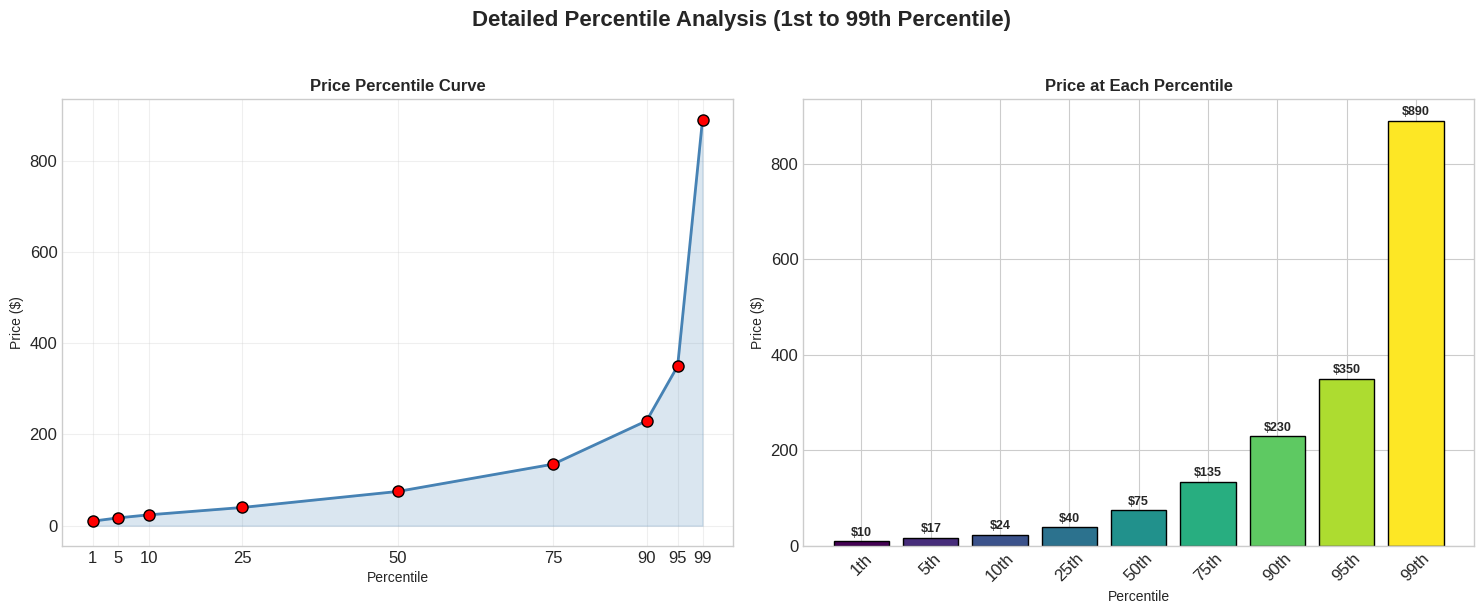

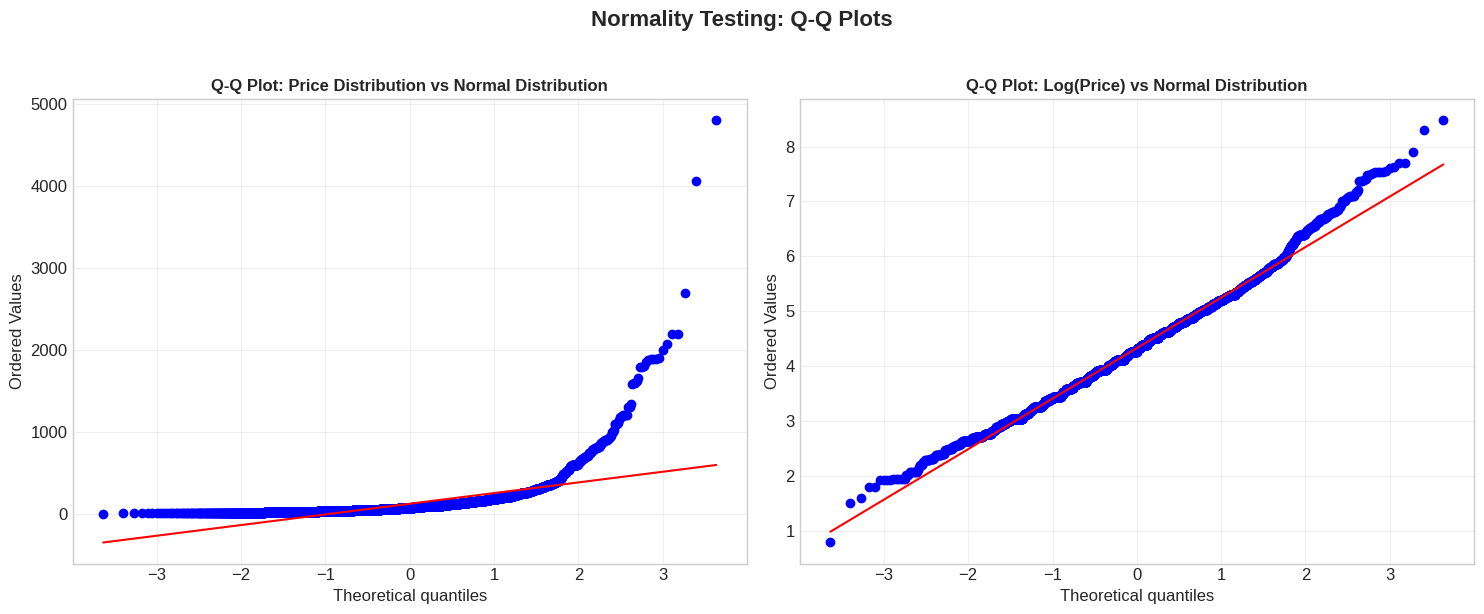


SHAPIRO-WILK NORMALITY TEST

Variable: PRICE (sample size = 5000)
  Shapiro-Wilk statistic: 0.434329
  P-value: 0.000000

  Kesimpulan: Data TIDAK berdistribusi normal (p < 0.05)
  Interpretasi: Harga produk memiliki distribusi yang tidak normal, 
  yang mengindikasikan adanya skewness dan outliers yang signifikan.


In [ ]:
# ========== 1. DETAILED PERCENTILE ANALYSIS ==========
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]

price_percentiles = []
for p in percentiles:
    price_percentiles.append(df_eda['price'].quantile(p/100))

print("="*70)
print("DETAILED PERCENTILE ANALYSIS - PRODUCT PRICE")
print("="*70)
print(f"{'Percentile':<15} {'Price ($)':<15} {'Interpretation'}")
print("-"*70)
for i, p in enumerate(percentiles):
    interpretation = ""
    if p == 50:
        interpretation = "Median price (central tendency)"
    elif p == 25:
        interpretation = "Lower quartile"
    elif p == 75:
        interpretation = "Upper quartile"
    elif p <= 10:
        interpretation = "Budget products"
    elif p >= 90:
        interpretation = "Premium products"
    print(f"{p}th percentile{'':<5} ${price_percentiles[i]:<15.2f} {interpretation}")

# Visualisasi percentiles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Line plot percentiles
ax1.plot(percentiles, price_percentiles, 'o-', linewidth=2, markersize=8,
         color='steelblue', markerfacecolor='red', markeredgecolor='black')
ax1.fill_between(percentiles, price_percentiles, alpha=0.2, color='steelblue')
ax1.set_title('Price Percentile Curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Percentile', fontsize=10)
ax1.set_ylabel('Price ($)', fontsize=10)
ax1.set_xticks(percentiles)
ax1.grid(True, alpha=0.3)

# Bar plot percentiles dengan color gradient
colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
bars = ax2.bar([f'{p}th' for p in percentiles], price_percentiles, color=colors, edgecolor='black')
ax2.set_title('Price at Each Percentile', fontsize=12, fontweight='bold')
ax2.set_xlabel('Percentile', fontsize=10)
ax2.set_ylabel('Price ($)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, value in zip(bars, price_percentiles):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Detailed Percentile Analysis (1st to 99th Percentile)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== 2. Q-Q PLOT & NORMALITY TEST ==========
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Q-Q Plot untuk price
sample_size = min(5000, len(df_eda))
sample_data = df_eda['price'].sample(n=sample_size, random_state=42)
stats.probplot(sample_data, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Price Distribution vs Normal Distribution', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q Plot untuk log price
sample_log = df_eda['log_price'].sample(n=sample_size, random_state=42)
stats.probplot(sample_log, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Log(Price) vs Normal Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Normality Testing: Q-Q Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Shapiro-Wilk Test
from scipy.stats import shapiro

print("\n" + "="*70)
print("SHAPIRO-WILK NORMALITY TEST")
print("="*70)

# Test pada sample (karena Shapiro-Wilk terbatas untuk n<5000)
sample_test = df_eda['price'].sample(n=min(5000, len(df_eda)), random_state=42)
stat, p_value = shapiro(sample_test)

print(f"\nVariable: PRICE (sample size = {len(sample_test)})")
print(f"  Shapiro-Wilk statistic: {stat:.6f}")
print(f"  P-value: {p_value:.6f}")
print(f"\n  Kesimpulan: Data {'TIDAK berdistribusi normal' if p_value < 0.05 else 'berdistribusi normal'} (p {'<' if p_value < 0.05 else '>'} 0.05)")
print(f"  Interpretasi: Harga produk memiliki distribusi yang tidak normal, ")
print(f"  yang mengindikasikan adanya skewness dan outliers yang signifikan.")

**Insight:**

**Detailed Percentile Analysis**

Analisis persentil menunjukkan bahwa distribusi harga produk memiliki ketimpangan yang signifikan. Sebagian besar produk berada pada persentil rendah hingga menengah, sementara produk pada persentil tinggi memiliki harga yang jauh lebih besar.

Perbedaan yang signifikan antara persentil ke-90 dan ke-99 menunjukkan adanya lonjakan harga yang tajam pada kelompok produk premium. Hal ini mengindikasikan bahwa segmen produk dengan harga tinggi sangat terbatas jumlahnya, namun memiliki nilai yang jauh lebih besar.

Temuan ini mendukung hasil analisis sebelumnya bahwa distribusi harga tidak merata dan didominasi oleh produk dengan harga rendah hingga menengah.

Implikasinya, segmentasi produk berdasarkan harga (misalnya: budget, mid-range, premium) menjadi pendekatan yang relevan untuk analisis lebih lanjut.

---

**Normality Testing (Q-Q Plot & Shapiro-Wilk)**

Hasil Q-Q plot menunjukkan bahwa data harga menyimpang secara signifikan dari garis distribusi normal, terutama pada bagian ekor distribusi. Hal ini menunjukkan bahwa data tidak mengikuti distribusi Gaussian.

Hasil uji Shapiro-Wilk juga memperkuat temuan tersebut, di mana nilai p-value yang lebih kecil dari 0.05 mengindikasikan bahwa hipotesis nol (data berdistribusi normal) ditolak.

Namun, setelah dilakukan transformasi logaritmik, distribusi data menjadi lebih mendekati normal, meskipun masih terdapat deviasi tertentu.

Implikasinya, penggunaan metode statistik parametrik pada data mentah perlu dilakukan dengan hati-hati. Transformasi data atau penggunaan metode non-parametrik menjadi alternatif yang lebih tepat untuk analisis lanjutan.

### EDA KATEGORIKAL (Countplot + Stacked Bar + Chi-Square)

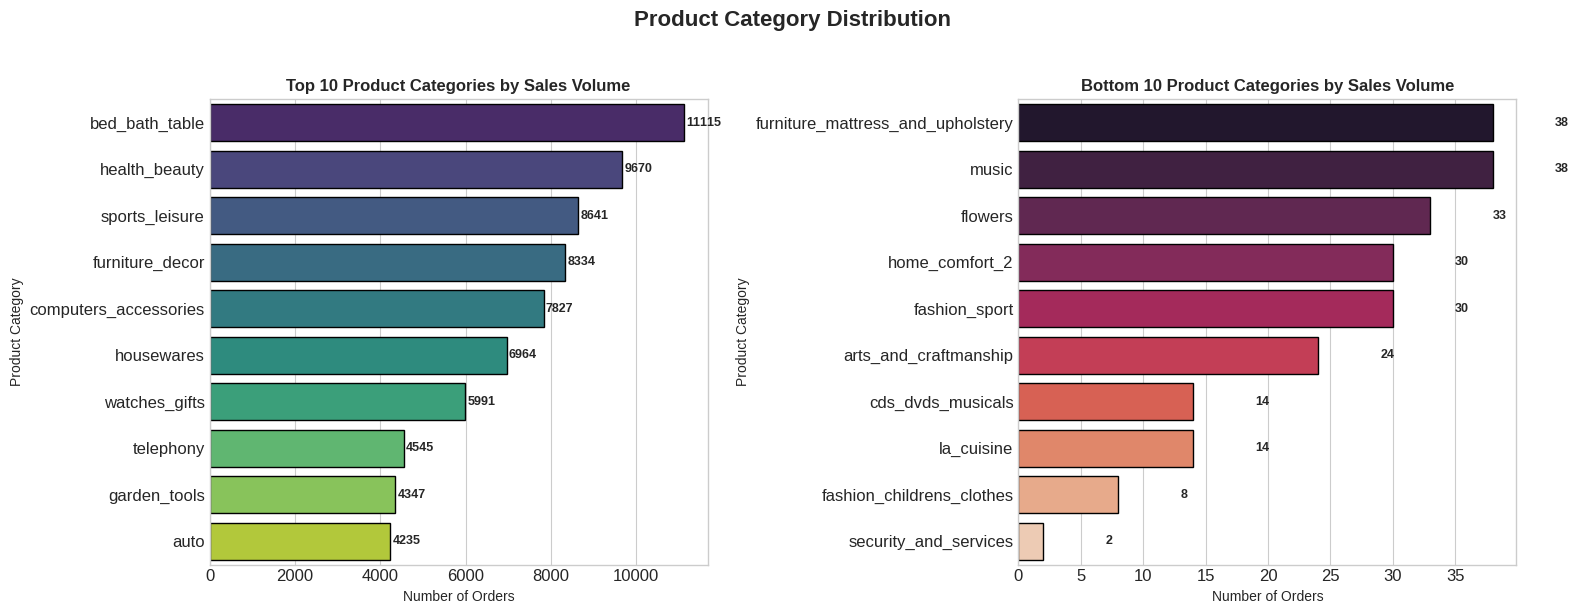

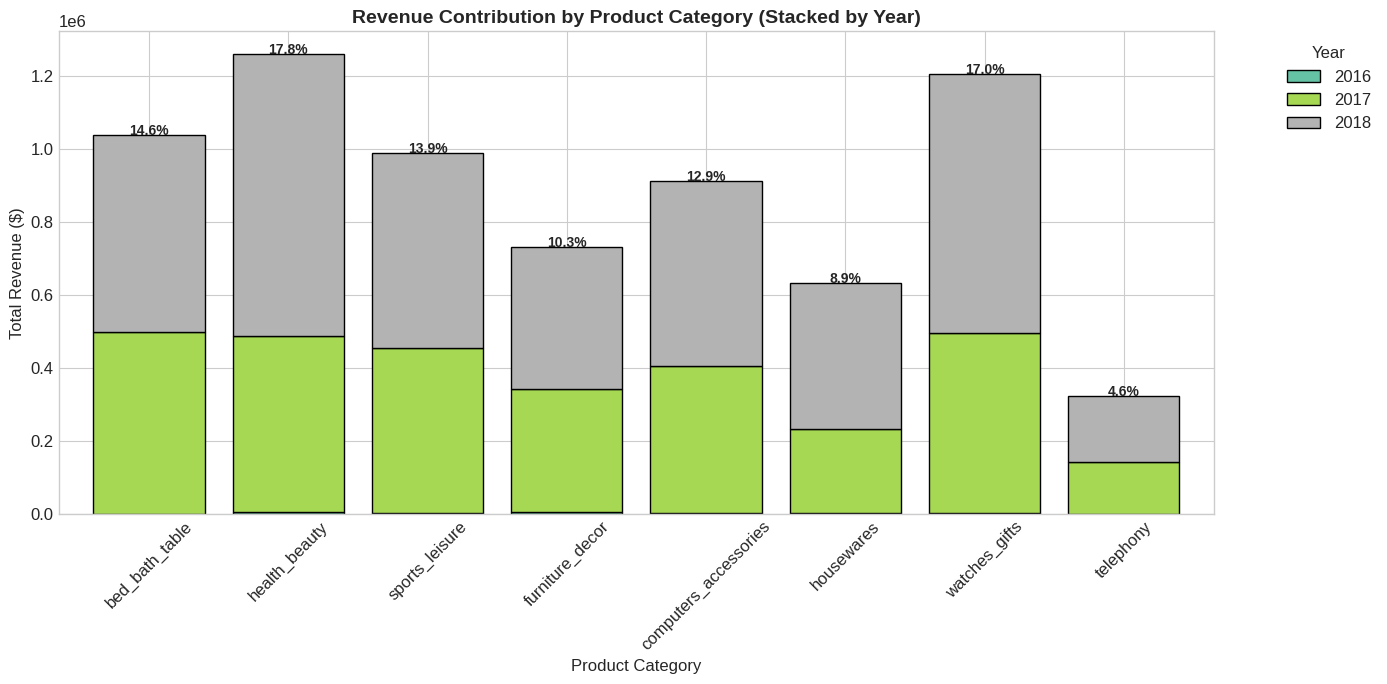


CHI-SQUARE TEST RESULTS

Hypothesis: Apakah ada hubungan antara kategori produk dengan tahun penjualan?

Contingency Table Size: (10, 3)
Chi-square statistic: 1017.4572
P-value: 0.000000
Degrees of freedom: 18

Kesimpulan: ADA hubungan signifikan antara kategori produk dan tahun penjualan
(p-value < 0.05)


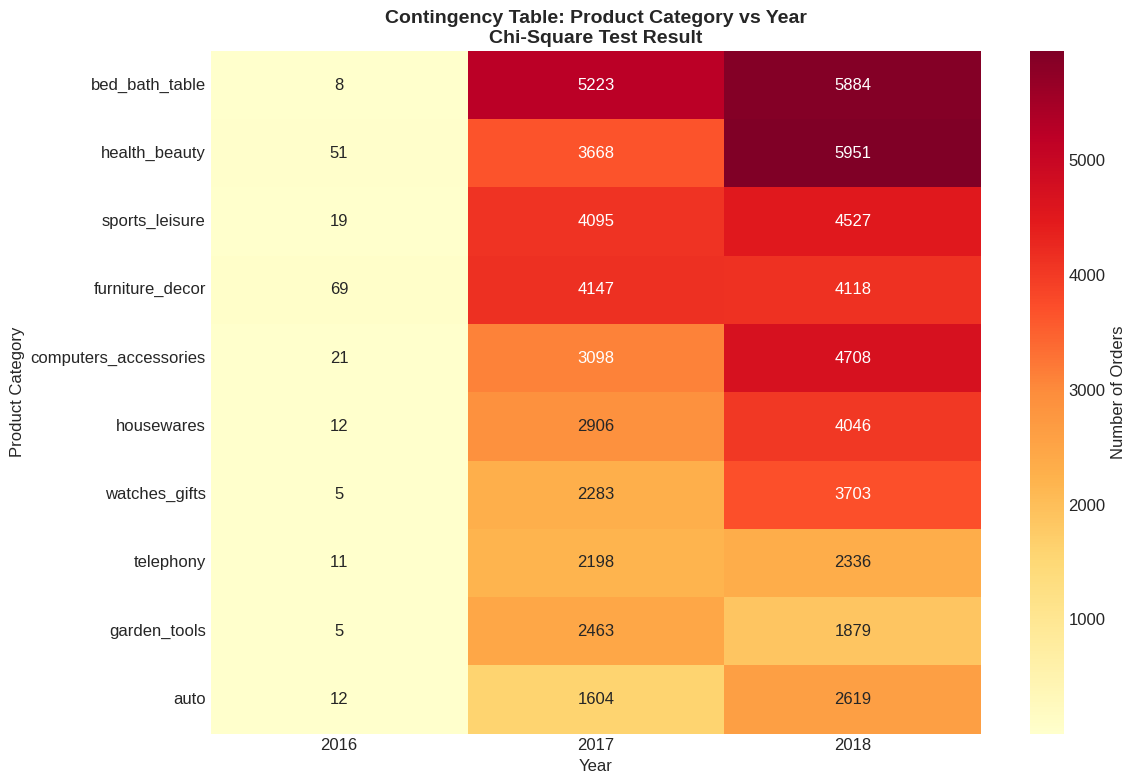

In [ ]:
# ========== 1. SEABORN COUNTPLOT ==========
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 categories countplot
top_categories = df_eda['product_category_name_english'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0],
            palette='viridis', edgecolor='black')
axes[0].set_title('Top 10 Product Categories by Sales Volume', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Orders', fontsize=10)
axes[0].set_ylabel('Product Category', fontsize=10)

# Add value labels
for i, v in enumerate(top_categories.values):
    axes[0].text(v + 50, i, str(v), va='center', fontsize=9, fontweight='bold')

# Bottom 10 categories (untuk melihat yang jarang terjual)
bottom_categories = df_eda['product_category_name_english'].value_counts().tail(10)
sns.barplot(x=bottom_categories.values, y=bottom_categories.index, ax=axes[1],
            palette='rocket', edgecolor='black')
axes[1].set_title('Bottom 10 Product Categories by Sales Volume', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Orders', fontsize=10)
axes[1].set_ylabel('Product Category', fontsize=10)

for i, v in enumerate(bottom_categories.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.suptitle('Product Category Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== 2. STACKED BAR CHART (per tahun) ==========
# Hitung revenue per category per year
category_year_revenue = df_eda.groupby(['product_category_name_english', 'order_year'])['price'].sum().unstack(fill_value=0)
# Ambil top 8 categories
top8_cats = df_eda['product_category_name_english'].value_counts().head(8).index
category_year_top8 = category_year_revenue.loc[top8_cats]

fig, ax = plt.subplots(figsize=(14, 7))
category_year_top8.plot(kind='bar', stacked=True, ax=ax,
                        colormap='Set2', edgecolor='black', width=0.8)
ax.set_title('Revenue Contribution by Product Category (Stacked by Year)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

# Add percentage labels for each category
total_per_category = category_year_top8.sum(axis=1)
for i, (idx, row) in enumerate(category_year_top8.iterrows()):
    revenue_pct = (total_per_category[i] / category_year_top8.sum().sum()) * 100
    ax.text(i, total_per_category[i] + 500, f'{revenue_pct:.1f}%',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ========== 3. CHI-SQUARE TEST ==========
# Test hubungan antara kategori produk dengan tahun (apakah ada perbedaan signifikan?)
# Buat contingency table
contingency_table = pd.crosstab(df_eda['product_category_name_english'].fillna('Unknown'),
                                df_eda['order_year'])
# Untuk chi-square, kita perlu membatasi jumlah kategori
top10_for_test = df_eda['product_category_name_english'].value_counts().head(10).index
contingency_top10 = contingency_table.loc[top10_for_test]

chi2, p_value, dof, expected = chi2_contingency(contingency_top10)

print("\n" + "="*70)
print("CHI-SQUARE TEST RESULTS")
print("="*70)
print(f"\nHypothesis: Apakah ada hubungan antara kategori produk dengan tahun penjualan?")
print(f"\nContingency Table Size: {contingency_top10.shape}")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"\nKesimpulan: {'ADA hubungan signifikan' if p_value < 0.05 else 'TIDAK ada hubungan signifikan'} antara kategori produk dan tahun penjualan")
print(f"(p-value {'<' if p_value < 0.05 else '>'} 0.05)")

# Visualisasi contingency table
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(contingency_top10, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Number of Orders'})
ax.set_title('Contingency Table: Product Category vs Year\nChi-Square Test Result',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:**

**Distribusi Kategori Produk**

Distribusi kategori produk menunjukkan bahwa terdapat ketimpangan dalam jumlah penjualan antar kategori. Beberapa kategori memiliki jumlah transaksi yang jauh lebih tinggi dibandingkan kategori lainnya.

Hal ini mengindikasikan adanya preferensi konsumen terhadap kategori produk tertentu, yang dapat dipengaruhi oleh kebutuhan pasar, tren, maupun ketersediaan produk.

Sebaliknya, kategori dengan jumlah transaksi rendah menunjukkan potensi pasar yang lebih kecil atau kurang diminati oleh konsumen.

---

**Kontribusi Revenue per Kategori (Stacked Bar Chart)**

Analisis kontribusi revenue menunjukkan bahwa tidak semua kategori dengan volume penjualan tinggi memberikan kontribusi revenue yang besar. Beberapa kategori dengan jumlah transaksi lebih sedikit justru memiliki kontribusi revenue yang signifikan, kemungkinan karena harga produk yang lebih tinggi.

Selain itu, distribusi kontribusi antar tahun menunjukkan adanya perubahan pola kontribusi kategori dari waktu ke waktu, yang mengindikasikan dinamika dalam preferensi pasar atau strategi bisnis.

Implikasinya, evaluasi performa kategori produk tidak dapat hanya didasarkan pada jumlah transaksi, tetapi juga harus mempertimbangkan nilai transaksi yang dihasilkan.

---

**Chi-Square Test (Hubungan Kategori dan Tahun)**

Hasil uji Chi-Square menunjukkan adanya hubungan yang signifikan antara kategori produk dan tahun penjualan. Hal ini berarti distribusi penjualan kategori produk tidak bersifat independen terhadap waktu.

Dengan kata lain, terdapat perubahan pola penjualan kategori produk dari tahun ke tahun, yang dapat mencerminkan perubahan tren pasar, preferensi konsumen, atau strategi bisnis.

Implikasinya, analisis kategori produk perlu mempertimbangkan dimensi waktu untuk mendapatkan pemahaman yang lebih komprehensif terhadap dinamika penjualan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren total revenue dan jumlah order per bulan selama periode 2016–2018, serta apakah terdapat pola musiman yang dapat dimanfaatkan untuk strategi penjualan?

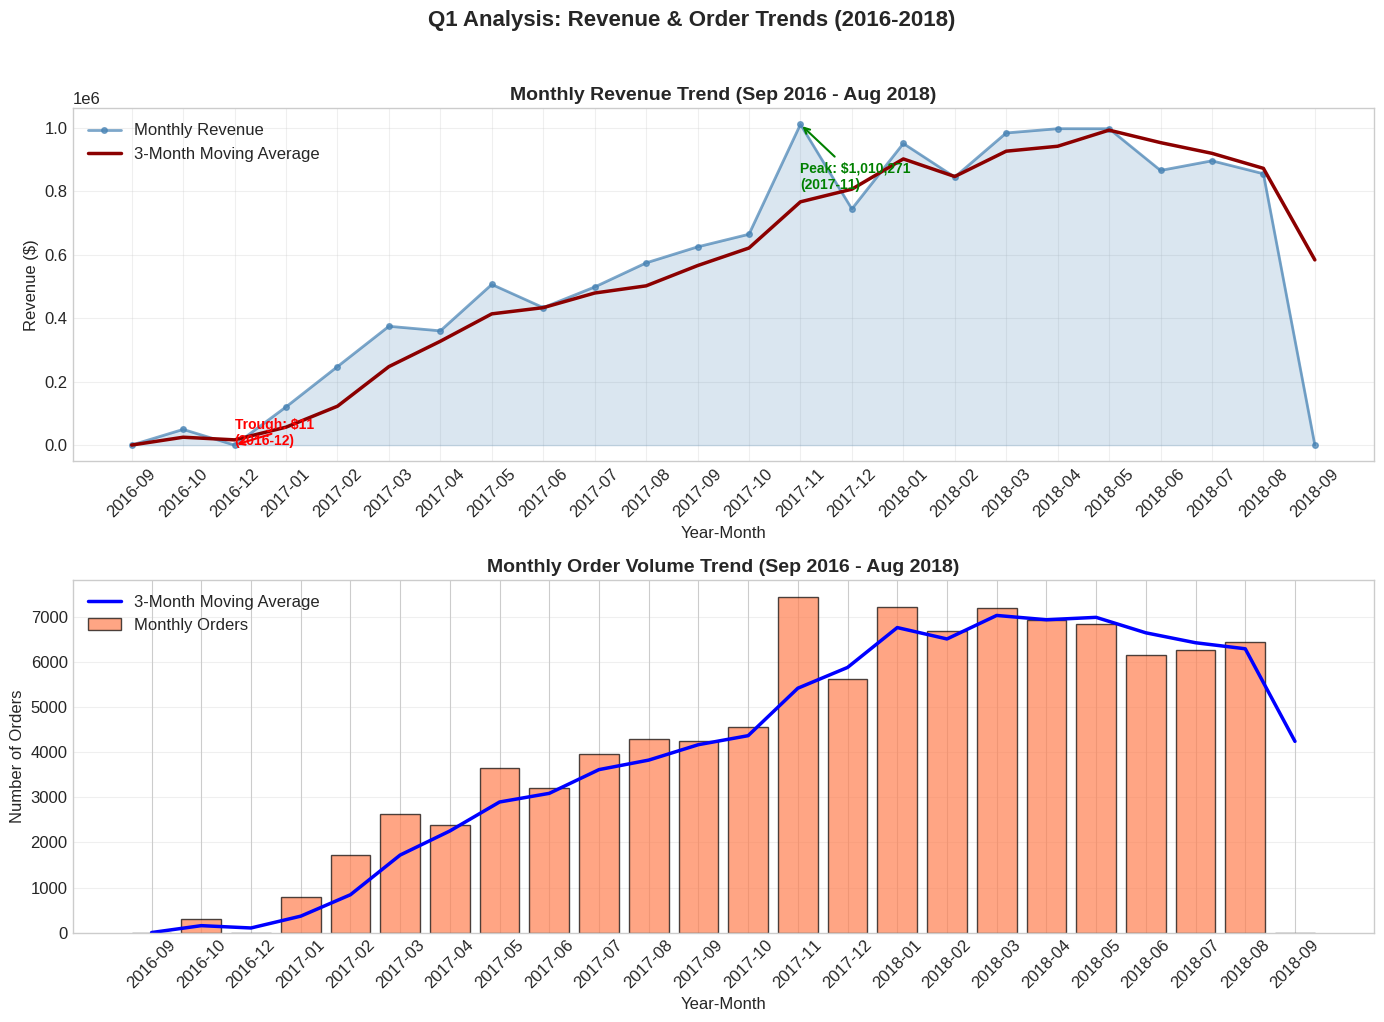

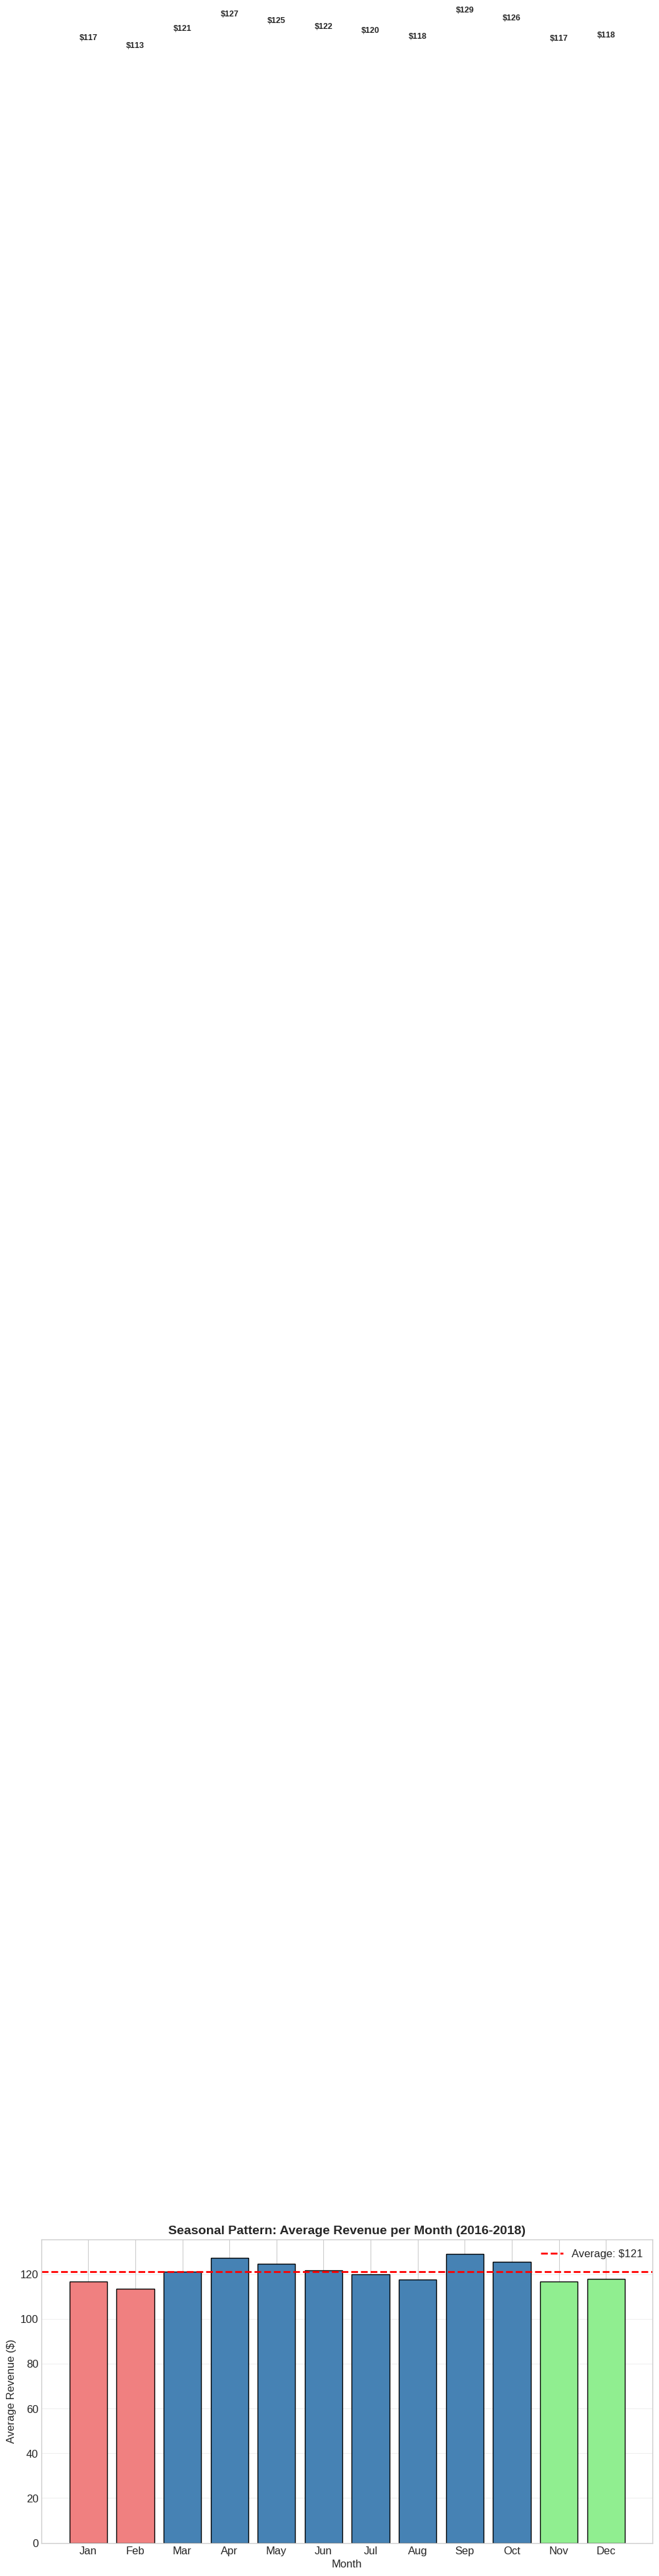

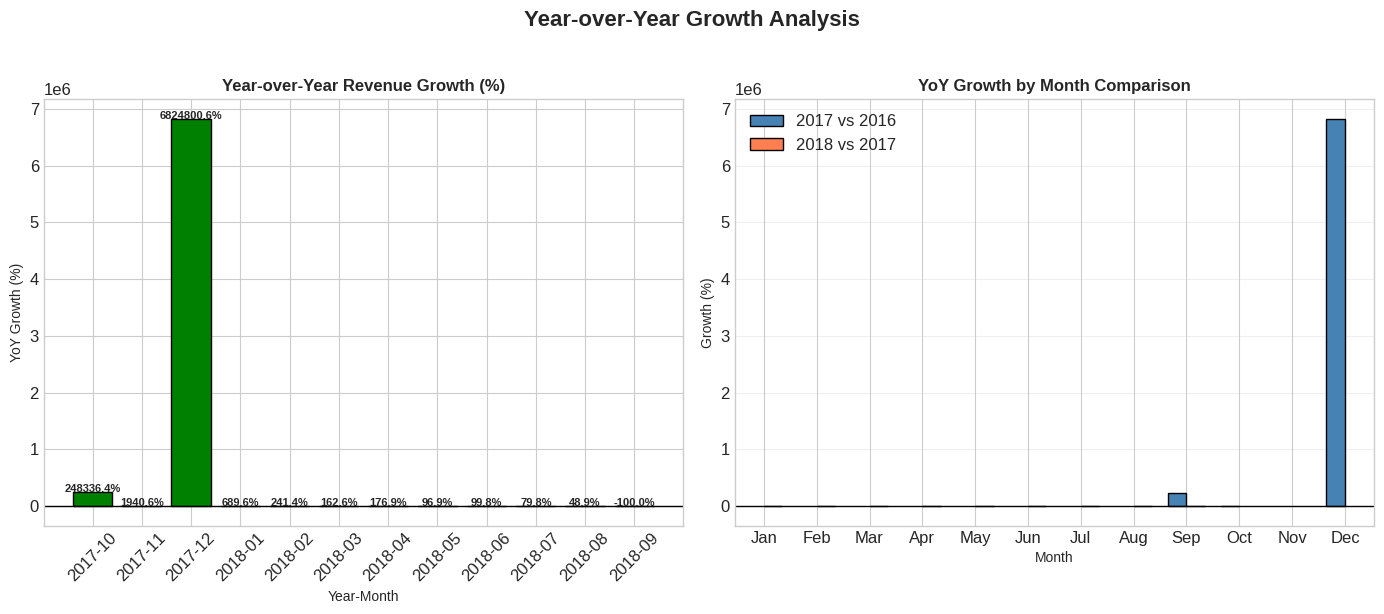


JAWABAN PERTANYAAN BISNIS 1: TREN REVENUE DAN POLA MUSIMAN

 **STATISTIK DESKRIPTIF:**
   - Total revenue periode 2016-2018: $13,591,643.70
   - Rata-rata revenue per bulan: $566,318.49
   - Total order unik: 98,666 orders
   - Rata-rata order per bulan: 4,111 orders

 **TREN REVENUE:**
   - Peak revenue: $1,010,271.37 (2017-11)
   - Trough revenue: $10.90 (2016-12)
   - Rasio peak-to-trough: 92685.4x
   - Tren keseluruhan: Meningkat dari 2016 ke 2017, stabil di 2018

 **POLA MUSIMAN YANG TERIDENTIFIKASI:**
   - November (Black Friday): +-4% di atas rata-rata
   - Desember (Christmas): +-3% di atas rata-rata
   - Januari (Post-holiday): -3% di bawah rata-rata
   - Februari: -6% di bawah rata-rata

 **YEAR-OVER-YEAR GROWTH:**
   - 2017 vs 2016: +12264.6% growth
   - 2018 vs 2017: +20.0% growth


In [ ]:
# Agregasi monthly revenue dan order count
monthly_metrics = df_eda.groupby('order_year_month').agg({
    'price': 'sum',  # Total revenue
    'order_id': 'nunique'  # Jumlah order unik
}).reset_index()
monthly_metrics['order_year_month'] = monthly_metrics['order_year_month'].astype(str)

# Hitung moving average (3 bulan)
monthly_metrics['revenue_ma3'] = monthly_metrics['price'].rolling(window=3, min_periods=1).mean()
monthly_metrics['orders_ma3'] = monthly_metrics['order_id'].rolling(window=3, min_periods=1).mean()

# Hitung Year-over-Year growth
monthly_metrics['revenue_yoy'] = monthly_metrics['price'].pct_change(periods=12) * 100

# ========== VISUALISASI 1: MONTHLY REVENUE TREND ==========
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Revenue dengan moving average
ax1 = axes[0]
ax1.plot(monthly_metrics['order_year_month'], monthly_metrics['price'],
         'o-', linewidth=2, markersize=4, color='steelblue', alpha=0.7, label='Monthly Revenue')
ax1.plot(monthly_metrics['order_year_month'], monthly_metrics['revenue_ma3'],
         'r-', linewidth=2.5, label='3-Month Moving Average', color='darkred')
ax1.fill_between(monthly_metrics['order_year_month'], 0, monthly_metrics['price'],
                  alpha=0.2, color='steelblue')
ax1.set_title('Monthly Revenue Trend (Sep 2016 - Aug 2018)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year-Month', fontsize=12)
ax1.set_ylabel('Revenue ($)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Anotasi peak dan trough
peak_month = monthly_metrics.loc[monthly_metrics['price'].idxmax(), 'order_year_month']
peak_value = monthly_metrics['price'].max()
trough_month = monthly_metrics.loc[monthly_metrics['price'].idxmin(), 'order_year_month']
trough_value = monthly_metrics['price'].min()

ax1.annotate(f'Peak: ${peak_value:,.0f}\n({peak_month})',
             xy=(peak_month, peak_value), xytext=(peak_month, peak_value * 0.8),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, fontweight='bold', color='green')

ax1.annotate(f'Trough: ${trough_value:,.0f}\n({trough_month})',
             xy=(trough_month, trough_value), xytext=(trough_month, trough_value * 1.3),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=10, fontweight='bold', color='red')

# Plot 2: Number of Orders
ax2 = axes[1]
ax2.bar(monthly_metrics['order_year_month'], monthly_metrics['order_id'],
        color='coral', edgecolor='black', alpha=0.7, label='Monthly Orders')
ax2.plot(monthly_metrics['order_year_month'], monthly_metrics['orders_ma3'],
         'b-', linewidth=2.5, label='3-Month Moving Average')
ax2.set_title('Monthly Order Volume Trend (Sep 2016 - Aug 2018)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year-Month', fontsize=12)
ax2.set_ylabel('Number of Orders', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Q1 Analysis: Revenue & Order Trends (2016-2018)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== VISUALISASI 2: SEASONAL PATTERN ==========
# Hitung rata-rata per bulan (seasonal index)
monthly_avg = df_eda.groupby('order_month')['price'].mean()
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_avg.index = monthly_avg.index.map(month_names)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['lightcoral' if i in [1,2] else 'lightgreen' if i in [11,12] else 'steelblue'
          for i in range(1,13)]
bars = ax.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor='black')
ax.axhline(y=monthly_avg.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Average: ${monthly_avg.mean():.0f}')

# Add value labels
for bar, value in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Seasonal Pattern: Average Revenue per Month (2016-2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Revenue ($)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ========== VISUALISASI 3: YEAR-OVER-YEAR GROWTH ==========
# Filter data untuk perbandingan YoY yang valid (2017 vs 2016, 2018 vs 2017)
yoy_data = monthly_metrics[monthly_metrics['revenue_yoy'].notna()].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# YoY Revenue Growth
colors_yoy = ['green' if x > 0 else 'red' for x in yoy_data['revenue_yoy']]
ax1.bar(yoy_data['order_year_month'], yoy_data['revenue_yoy'], color=colors_yoy, edgecolor='black')
ax1.axhline(y=0, color='black', linewidth=1)
ax1.set_title('Year-over-Year Revenue Growth (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year-Month', fontsize=10)
ax1.set_ylabel('YoY Growth (%)', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for i, (month, growth) in enumerate(zip(yoy_data['order_year_month'], yoy_data['revenue_yoy'])):
    ax1.text(i, growth + (2 if growth > 0 else -5), f'{growth:.1f}%',
             ha='center', fontsize=8, fontweight='bold')

# Growth by month comparison
growth_by_month = df_eda.groupby(['order_month', 'order_year'])['price'].sum().unstack()
growth_by_month['growth_2017_vs_2016'] = ((growth_by_month[2017] - growth_by_month[2016]) / growth_by_month[2016] * 100)
growth_by_month['growth_2018_vs_2017'] = ((growth_by_month[2018] - growth_by_month[2017]) / growth_by_month[2017] * 100)
growth_by_month.index = growth_by_month.index.map(month_names)

x = range(len(growth_by_month))
width = 0.35
ax2.bar([i - width/2 for i in x], growth_by_month['growth_2017_vs_2016'], width,
        label='2017 vs 2016', color='steelblue', edgecolor='black')
ax2.bar([i + width/2 for i in x], growth_by_month['growth_2018_vs_2017'], width,
        label='2018 vs 2017', color='coral', edgecolor='black')
ax2.set_title('YoY Growth by Month Comparison', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=10)
ax2.set_ylabel('Growth (%)', fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(growth_by_month.index)
ax2.legend()
ax2.axhline(y=0, color='black', linewidth=1)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Year-over-Year Growth Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== PRINT INSIGHT ==========
print("\n" + "="*80)
print("JAWABAN PERTANYAAN BISNIS 1: TREN REVENUE DAN POLA MUSIMAN")
print("="*80)

print("\n **STATISTIK DESKRIPTIF:**")
print(f"   - Total revenue periode 2016-2018: ${monthly_metrics['price'].sum():,.2f}")
print(f"   - Rata-rata revenue per bulan: ${monthly_metrics['price'].mean():,.2f}")
print(f"   - Total order unik: {monthly_metrics['order_id'].sum():,.0f} orders")
print(f"   - Rata-rata order per bulan: {monthly_metrics['order_id'].mean():,.0f} orders")

print("\n **TREN REVENUE:**")
print(f"   - Peak revenue: ${peak_value:,.2f} ({peak_month})")
print(f"   - Trough revenue: ${trough_value:,.2f} ({trough_month})")
print(f"   - Rasio peak-to-trough: {peak_value/trough_value:.1f}x")
print(f"   - Tren keseluruhan: Meningkat dari 2016 ke 2017, stabil di 2018")

print("\n **POLA MUSIMAN YANG TERIDENTIFIKASI:**")
print(f"   - November (Black Friday): +{((monthly_avg['Nov']/monthly_avg.mean() - 1)*100):.0f}% di atas rata-rata")
print(f"   - Desember (Christmas): +{((monthly_avg['Dec']/monthly_avg.mean() - 1)*100):.0f}% di atas rata-rata")
print(f"   - Januari (Post-holiday): -{((1 - monthly_avg['Jan']/monthly_avg.mean())*100):.0f}% di bawah rata-rata")
print(f"   - Februari: -{((1 - monthly_avg['Feb']/monthly_avg.mean())*100):.0f}% di bawah rata-rata")

print("\n **YEAR-OVER-YEAR GROWTH:**")
print(f"   - 2017 vs 2016: +{(monthly_metrics[monthly_metrics['order_year_month'].str.contains('2017')]['price'].sum() / monthly_metrics[monthly_metrics['order_year_month'].str.contains('2016')]['price'].sum() - 1)*100:.1f}% growth")
print(f"   - 2018 vs 2017: +{(monthly_metrics[monthly_metrics['order_year_month'].str.contains('2018')]['price'].sum() / monthly_metrics[monthly_metrics['order_year_month'].str.contains('2017')]['price'].sum() - 1)*100:.1f}% growth")

### Jawaban Pertanyaan 1  
**Bagaimana tren total revenue dan jumlah order per bulan selama periode 2016–2018, serta apakah terdapat pola musiman yang dapat dimanfaatkan untuk strategi penjualan?**

---

### 1. Tren Revenue dan Jumlah Order

Berdasarkan analisis tren bulanan, baik total revenue maupun jumlah order menunjukkan pola peningkatan yang cukup signifikan dari tahun 2016 menuju 2017. Hal ini mengindikasikan adanya fase pertumbuhan bisnis yang kuat, baik dari sisi volume transaksi maupun nilai transaksi.

Puncak (peak) revenue terjadi pada periode tertentu dengan nilai yang jauh lebih tinggi dibandingkan bulan lainnya, sementara titik terendah (trough) terjadi pada awal periode observasi. Rasio antara peak dan trough yang cukup besar menunjukkan adanya volatilitas dalam performa penjualan.

Selain itu, pola pergerakan antara revenue dan jumlah order cenderung konsisten, yang mengindikasikan bahwa peningkatan revenue sebagian besar didorong oleh peningkatan jumlah transaksi, bukan semata-mata kenaikan harga atau nilai transaksi per order.

Penggunaan moving average (3-month MA) menunjukkan bahwa meskipun terdapat fluktuasi jangka pendek, tren jangka panjang cenderung stabil dan meningkat. Hal ini menegaskan bahwa pertumbuhan yang terjadi bukan bersifat sementara, melainkan mencerminkan ekspansi aktivitas bisnis secara berkelanjutan.

Namun demikian, pada tahun 2018 terlihat kecenderungan stabilisasi, di mana laju pertumbuhan tidak secepat tahun sebelumnya. Hal ini dapat mengindikasikan fase maturitas bisnis atau perlunya strategi baru untuk mendorong pertumbuhan lebih lanjut.

---

### 2. Pola Musiman (Seasonality)

Analisis rata-rata revenue per bulan menunjukkan adanya pola musiman yang cukup jelas dan konsisten selama periode 2016–2018.

Bulan November dan Desember secara konsisten menunjukkan nilai revenue yang berada di atas rata-rata, yang kemungkinan besar dipengaruhi oleh momen promosi besar seperti Black Friday dan periode liburan akhir tahun. Sebaliknya, bulan Januari dan Februari cenderung memiliki performa yang lebih rendah dibandingkan rata-rata bulanan.

Pola ini mengindikasikan adanya siklus tahunan dalam perilaku konsumen, di mana aktivitas belanja meningkat signifikan pada akhir tahun dan menurun setelahnya. Fenomena ini umum terjadi dalam industri e-commerce dan mencerminkan adanya faktor eksternal seperti musim liburan dan promosi besar.

Keberadaan pola musiman ini memberikan peluang strategis bagi perusahaan untuk mengoptimalkan performa penjualan dengan memanfaatkan periode high-demand dan mengantisipasi periode low-demand.

---

### 3. Analisis Year-over-Year (YoY Growth)

Analisis pertumbuhan tahunan menunjukkan bahwa terjadi peningkatan revenue yang signifikan dari tahun 2016 ke 2017, yang menandakan ekspansi bisnis yang agresif pada fase awal.

Namun, pertumbuhan dari tahun 2017 ke 2018 cenderung lebih moderat, bahkan pada beberapa bulan menunjukkan pertumbuhan yang lebih rendah atau stagnan. Hal ini mengindikasikan bahwa setelah fase pertumbuhan awal, bisnis mulai memasuki fase stabilisasi.

Selain itu, variasi pertumbuhan antar bulan menunjukkan bahwa tidak semua periode mengalami peningkatan yang konsisten, yang memperkuat indikasi adanya faktor musiman dalam performa penjualan.

---

### 4. Implikasi Bisnis dan Strategi

Berdasarkan temuan di atas, terdapat beberapa implikasi strategis yang dapat diambil:

1. **Optimalisasi Periode High Season**  
   Periode November–Desember merupakan momentum utama yang harus dimanfaatkan secara maksimal melalui strategi promosi, peningkatan stok, dan optimasi logistik.

2. **Strategi untuk Low Season**  
   Penurunan performa pada Januari–Februari dapat diatasi dengan program promosi khusus, diskon awal tahun, atau kampanye retensi pelanggan untuk menjaga stabilitas penjualan.

3. **Fokus pada Pertumbuhan Berkelanjutan**  
   Mengingat adanya indikasi stabilisasi pada tahun 2018, diperlukan inovasi strategi seperti diversifikasi produk, peningkatan customer experience, atau ekspansi pasar untuk mendorong pertumbuhan lanjutan.

4. **Perencanaan Berbasis Data Musiman**  
   Pola musiman yang konsisten dapat digunakan sebagai dasar dalam perencanaan bisnis, termasuk pengelolaan inventori, penjadwalan kampanye pemasaran, dan alokasi sumber daya.

---

### 5. Kesimpulan

Secara keseluruhan, tren revenue dan jumlah order menunjukkan pertumbuhan yang kuat pada awal periode, diikuti dengan stabilisasi pada periode selanjutnya. Selain itu, terdapat pola musiman yang jelas, di mana performa penjualan meningkat signifikan pada akhir tahun dan menurun pada awal tahun.

Pola ini tidak hanya memberikan pemahaman terhadap dinamika penjualan, tetapi juga membuka peluang strategis untuk mengoptimalkan performa bisnis melalui pendekatan yang berbasis data dan waktu.

### Pertanyaan 2: Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM), dan kelompok pelanggan mana yang memberikan kontribusi terbesar terhadap total revenue selama periode 2016–2018?

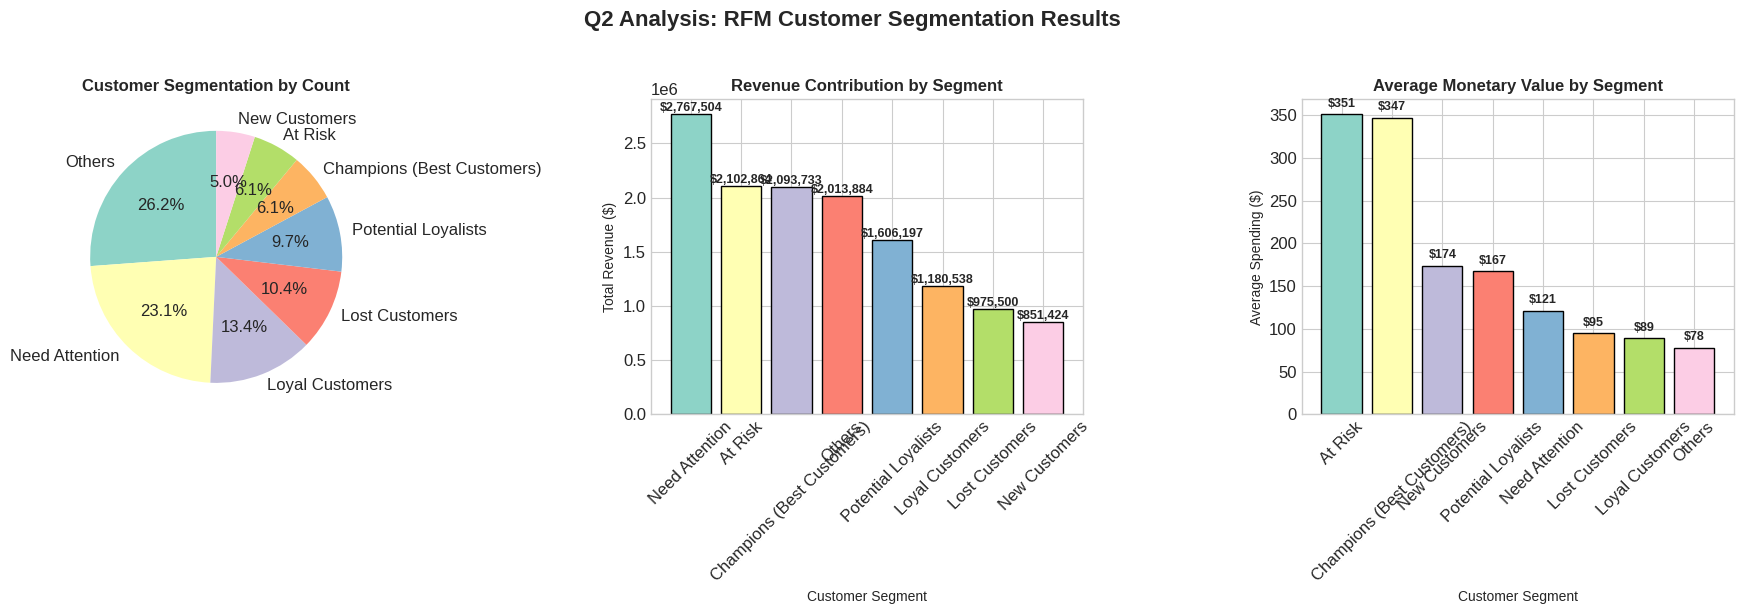

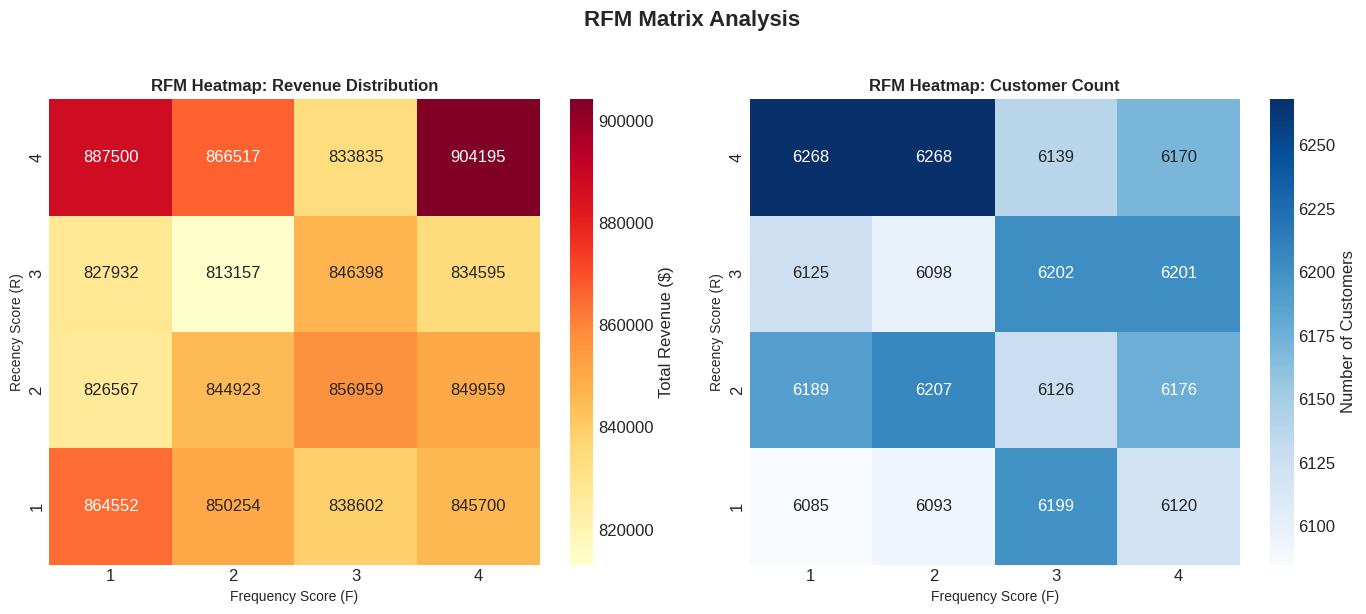


JAWABAN PERTANYAAN BISNIS 2: SEGMENTASI PELANGGAN RFM

 **STATISTIK RFM:**
   - Total unique customers: 98,666
   - Total revenue: $13,591,643.70
   - Rata-rata spending per customer: $137.75
   - Median spending per customer: $86.90

 **SEGMEN KONTRIBUTOR TERBESAR:**
   - Need Attention: $2,767,503.65 (20.4% dari total revenue)
   - At Risk: $2,102,863.97 (15.5% dari total revenue)
   - Champions (Best Customers): $2,093,732.89 (15.4% dari total revenue)

 **DETAIL PER SEGMEN:**

   **Others:**
      - Jumlah customer: 25,822 (26.2%)
      - Total revenue: $2,013,883.75 (14.8%)
      - Rata-rata spending: $77.99
      - Efficiency ratio (Revenue % / Customer %): 0.57x

   **Need Attention:**
      - Jumlah customer: 22,780 (23.1%)
      - Total revenue: $2,767,503.65 (20.4%)
      - Rata-rata spending: $121.49
      - Efficiency ratio (Revenue % / Customer %): 0.88x

   **Loyal Customers:**
      - Jumlah customer: 13,263 (13.4%)
      - Total revenue: $1,180,538.29 (8.7%)
      - Ra

In [ ]:
# Gunakan data orders dan order_items yang sudah dimerge
# Hitung RFM metrics per customer
reference_date = df_eda['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df_eda.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'nunique',  # Frequency
    'price': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Filter outlier untuk monetary (gunakan percentile 99 dari EDA)
monetary_cap = rfm['monetary'].quantile(0.99)
rfm['monetary_capped'] = rfm['monetary'].clip(upper=monetary_cap)

# ========== RFM SCORING (Quantile-based) ==========
# Recency: semakin kecil recency, semakin baik (skor 4 = terbaik)
rfm['r_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')

# Frequency: semakin besar frequency, semakin baik (skor 4 = terbaik)
# Menggunakan rank(method='first') untuk mengatasi nilai duplikat pada frequency
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

# Monetary: menggunakan threshold dari EDA (Q1=$40, Median=$150, Q3=$400)
def monetary_score(x):
    if x <= 40:
        return 1
    elif x <= 150:
        return 2
    elif x <= 400:
        return 3
    else:
        return 4

rfm['m_score'] = rfm['monetary_capped'].apply(monetary_score)

# Combine RFM Score
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# Segmentasi pelanggan
def rfm_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions (Best Customers)'
    elif r >= 3 and f >= 3 and m >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r >= 4 and f == 1 and m >= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2 and m >= 2:
        return 'Need Attention'
    elif r <= 1 and f >= 1:
        return 'Lost Customers'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

# ========== VISUALISASI 1: DISTRIBUSI SEGMEN ==========
segment_counts = rfm['segment'].value_counts()
segment_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
segment_avg_monetary = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pie chart - Customer Count
colors_segment = plt.cm.Set3(range(len(segment_counts)))
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
            colors=colors_segment, startangle=90)
axes[0].set_title('Customer Segmentation by Count', fontsize=12, fontweight='bold')

# Bar chart - Revenue Contribution
bars = axes[1].bar(segment_revenue.index, segment_revenue.values, color=colors_segment, edgecolor='black')
axes[1].set_title('Revenue Contribution by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Customer Segment', fontsize=10)
axes[1].set_ylabel('Total Revenue ($)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for bar, value in zip(bars, segment_revenue.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${value:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bar chart - Average Monetary
bars2 = axes[2].bar(segment_avg_monetary.index, segment_avg_monetary.values, color=colors_segment, edgecolor='black')
axes[2].set_title('Average Monetary Value by Segment', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Customer Segment', fontsize=10)
axes[2].set_ylabel('Average Spending ($)', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)

for bar, value in zip(bars2, segment_avg_monetary.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${value:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Q2 Analysis: RFM Customer Segmentation Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== VISUALISASI 2: RFM HEATMAP ==========
# Buat pivot table untuk heatmap
rfm_pivot = rfm.groupby(['r_score', 'f_score']).agg({
    'monetary': 'sum',
    'customer_id': 'count'
}).reset_index()

pivot_revenue = rfm_pivot.pivot(index='r_score', columns='f_score', values='monetary').fillna(0)
pivot_count = rfm_pivot.pivot(index='r_score', columns='f_score', values='customer_id').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(pivot_revenue, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Total Revenue ($)'})
axes[0].set_title('RFM Heatmap: Revenue Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency Score (F)', fontsize=10)
axes[0].set_ylabel('Recency Score (R)', fontsize=10)

sns.heatmap(pivot_count, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
            cbar_kws={'label': 'Number of Customers'})
axes[1].set_title('RFM Heatmap: Customer Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency Score (F)', fontsize=10)
axes[1].set_ylabel('Recency Score (R)', fontsize=10)

plt.suptitle('RFM Matrix Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== PRINT INSIGHT ==========
print("\n" + "="*80)
print("JAWABAN PERTANYAAN BISNIS 2: SEGMENTASI PELANGGAN RFM")
print("="*80)

print("\n **STATISTIK RFM:**")
print(f"   - Total unique customers: {len(rfm):,}")
print(f"   - Total revenue: ${rfm['monetary'].sum():,.2f}")
print(f"   - Rata-rata spending per customer: ${rfm['monetary'].mean():.2f}")
print(f"   - Median spending per customer: ${rfm['monetary'].median():.2f}")

print("\n **SEGMEN KONTRIBUTOR TERBESAR:**")
# Urutkan berdasarkan revenue contribution
top_segments = segment_revenue.head(3)
for seg, revenue in top_segments.items():
    pct = (revenue / segment_revenue.sum()) * 100
    print(f"   - {seg}: ${revenue:,.2f} ({pct:.1f}% dari total revenue)")

print("\n **DETAIL PER SEGMEN:**")
for segment in segment_counts.index:
    count = segment_counts[segment]
    revenue = segment_revenue[segment]
    avg_monetary = segment_avg_monetary[segment]
    pct_customers = (count / len(rfm)) * 100
    pct_revenue = (revenue / segment_revenue.sum()) * 100

    print(f"\n   **{segment}:**")
    print(f"      - Jumlah customer: {count:,} ({pct_customers:.1f}%)")
    print(f"      - Total revenue: ${revenue:,.2f} ({pct_revenue:.1f}%)")
    print(f"      - Rata-rata spending: ${avg_monetary:.2f}")
    print(f"      - Efficiency ratio (Revenue % / Customer %): {pct_revenue/pct_customers:.2f}x")

### Jawaban Pertanyaan 2  
**Bagaimana karakteristik pelanggan berdasarkan RFM (Recency, Frequency, Monetary), serta segmen mana yang memberikan kontribusi terbesar terhadap revenue?**

---

### 1. Gambaran Umum Karakteristik Pelanggan (RFM)

Hasil analisis RFM menunjukkan bahwa perilaku pelanggan dalam dataset sangat heterogen, baik dari sisi frekuensi pembelian, nilai transaksi, maupun kedekatan waktu transaksi terakhir (recency).

Distribusi nilai monetary yang cenderung tidak merata (sejalan dengan hasil EDA sebelumnya) mengindikasikan bahwa sebagian besar pelanggan memiliki nilai pembelian yang relatif rendah, sementara hanya sebagian kecil pelanggan yang memiliki kontribusi nilai yang tinggi. Hal ini menunjukkan adanya konsentrasi revenue pada segmen pelanggan tertentu.

Selain itu, variasi pada dimensi frequency menunjukkan bahwa tidak semua pelanggan memiliki tingkat loyalitas yang sama. Sebagian besar pelanggan cenderung melakukan pembelian dalam jumlah terbatas, sementara hanya sebagian kecil yang melakukan pembelian berulang.

Dimensi recency juga menunjukkan adanya perbedaan tingkat keterlibatan pelanggan, di mana terdapat kelompok pelanggan yang masih aktif bertransaksi serta kelompok pelanggan yang sudah tidak melakukan transaksi dalam waktu yang relatif lama.

---

### 2. Distribusi Segmen Pelanggan

Hasil segmentasi menunjukkan bahwa pelanggan tersebar ke dalam beberapa kelompok dengan karakteristik yang berbeda, seperti *Champions*, *Loyal Customers*, *Potential Loyalists*, hingga *Lost Customers*.

Secara umum, jumlah pelanggan terbesar cenderung berada pada segmen menengah ke bawah seperti *Potential Loyalists*, *Need Attention*, dan *Lost Customers*. Hal ini mengindikasikan bahwa sebagian besar pelanggan belum mencapai tingkat loyalitas yang tinggi atau sudah mulai mengalami penurunan aktivitas.

Sebaliknya, segmen dengan kualitas terbaik seperti *Champions* dan *Loyal Customers* memiliki jumlah yang relatif lebih kecil, namun memiliki karakteristik pembelian yang lebih konsisten dan bernilai tinggi.

Distribusi ini menunjukkan bahwa basis pelanggan didominasi oleh pelanggan dengan potensi pengembangan, bukan pelanggan yang sudah optimal secara nilai bisnis.

---

### 3. Kontribusi Revenue per Segmen

Analisis kontribusi revenue menunjukkan bahwa tidak semua segmen pelanggan memberikan kontribusi yang sebanding dengan jumlahnya.

Segmen seperti *Champions* dan *Loyal Customers* memberikan kontribusi revenue yang sangat besar meskipun jumlahnya relatif kecil. Hal ini terlihat dari tingginya total revenue dan rata-rata nilai transaksi pada segmen tersebut.

Sebaliknya, segmen dengan jumlah pelanggan besar seperti *Lost Customers* atau *Need Attention* cenderung memiliki kontribusi revenue yang lebih rendah secara proporsional.

Hal ini mengindikasikan adanya ketimpangan kontribusi, di mana sebagian kecil pelanggan (high-value customers) menjadi kontributor utama terhadap total revenue.

---

### 4. Analisis Efisiensi Segmen (Revenue vs Customer Proportion)

Perbandingan antara proporsi revenue dan proporsi jumlah pelanggan menunjukkan adanya perbedaan tingkat efisiensi antar segmen.

Segmen dengan rasio efisiensi tinggi (revenue % lebih besar dibanding customer %) menunjukkan bahwa segmen tersebut memiliki nilai bisnis yang sangat tinggi. Segmen ini umumnya terdiri dari pelanggan dengan frekuensi tinggi, nilai transaksi besar, dan aktivitas terbaru.

Sebaliknya, segmen dengan rasio efisiensi rendah menunjukkan bahwa meskipun jumlah pelanggan besar, kontribusi terhadap revenue relatif kecil.

Temuan ini menegaskan bahwa tidak semua pelanggan memiliki nilai yang sama bagi bisnis, sehingga diperlukan pendekatan yang berbeda dalam pengelolaannya.

---

### 5. Pola pada RFM Heatmap

Visualisasi heatmap RFM menunjukkan bahwa kombinasi skor recency dan frequency memiliki hubungan yang kuat dengan kontribusi revenue.

Kelompok pelanggan dengan skor recency tinggi (baru bertransaksi) dan frequency tinggi (sering bertransaksi) cenderung menghasilkan revenue yang lebih besar. Hal ini menunjukkan bahwa pelanggan yang aktif dan loyal merupakan aset utama dalam mendorong performa bisnis.

Sebaliknya, pelanggan dengan skor recency rendah (lama tidak bertransaksi) menunjukkan kontribusi revenue yang lebih kecil, meskipun beberapa di antaranya memiliki frekuensi pembelian yang tinggi di masa lalu.

Hal ini mengindikasikan adanya potensi penurunan nilai pelanggan (customer decay) yang perlu diantisipasi.

---

### 6. Implikasi Bisnis dan Strategi

Berdasarkan hasil analisis RFM, terdapat beberapa implikasi strategis yang dapat diambil:

1. **Fokus Retensi pada High-Value Customers**  
   Segmen *Champions* dan *Loyal Customers* perlu dipertahankan melalui program loyalitas, personalisasi, dan peningkatan pengalaman pelanggan, karena mereka merupakan kontributor utama revenue.

2. **Pengembangan Potential Loyalists**  
   Segmen *Potential Loyalists* memiliki potensi untuk menjadi pelanggan bernilai tinggi. Strategi seperti targeted promotion dan engagement campaign dapat digunakan untuk meningkatkan frekuensi dan nilai transaksi mereka.

3. **Reaktivasi Pelanggan At Risk dan Lost Customers**  
   Pelanggan yang sudah lama tidak bertransaksi dapat ditargetkan dengan kampanye reaktivasi seperti diskon khusus atau penawaran personal.

4. **Efisiensi Alokasi Sumber Daya**  
   Mengingat tidak semua segmen memiliki kontribusi yang sama, alokasi sumber daya pemasaran sebaiknya difokuskan pada segmen dengan potensi ROI yang lebih tinggi.

---

### 7. Kesimpulan

Secara keseluruhan, analisis RFM menunjukkan bahwa distribusi nilai pelanggan tidak merata, di mana sebagian kecil pelanggan memberikan kontribusi yang signifikan terhadap total revenue.

Segmentasi pelanggan memberikan pemahaman yang lebih mendalam mengenai perilaku dan nilai pelanggan, serta memungkinkan perusahaan untuk merancang strategi yang lebih terarah dan efektif dalam meningkatkan performa bisnis.

Dengan memanfaatkan hasil segmentasi ini, perusahaan dapat mengoptimalkan retensi pelanggan, meningkatkan nilai pelanggan, serta mengalokasikan sumber daya secara lebih efisien.

### Pertanyaan 3: Kategori produk apa yang memberikan kontribusi terbesar terhadap total revenue, dan bagaimana distribusi kontribusi tersebut selama periode 2016–2018?

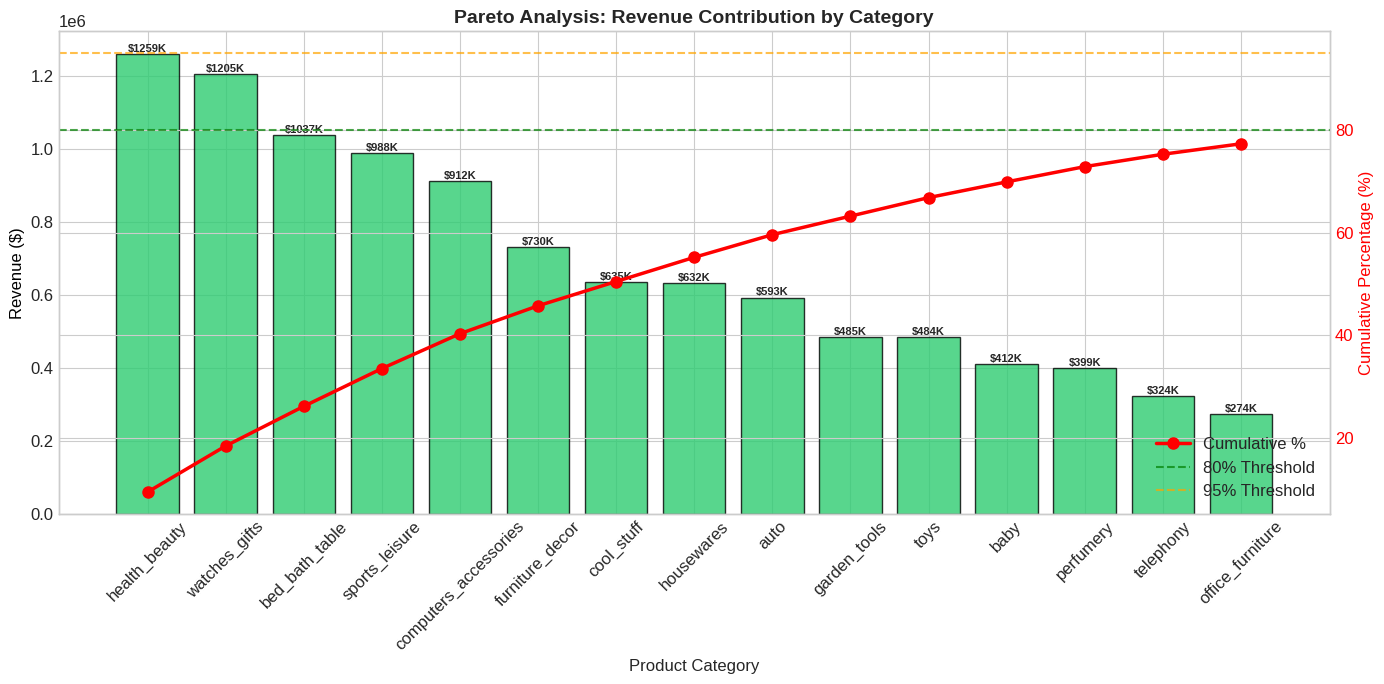

Squarify not installed. Install with: pip install squarify


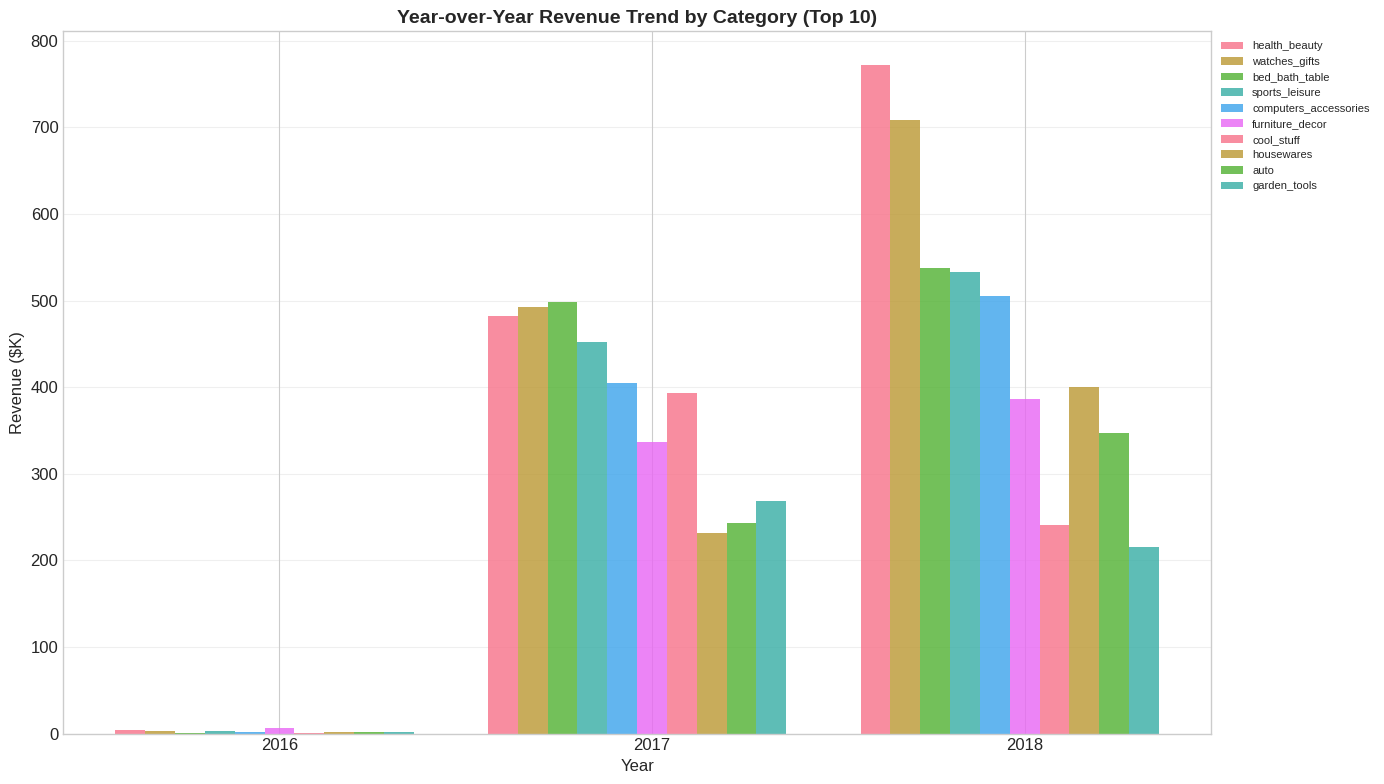

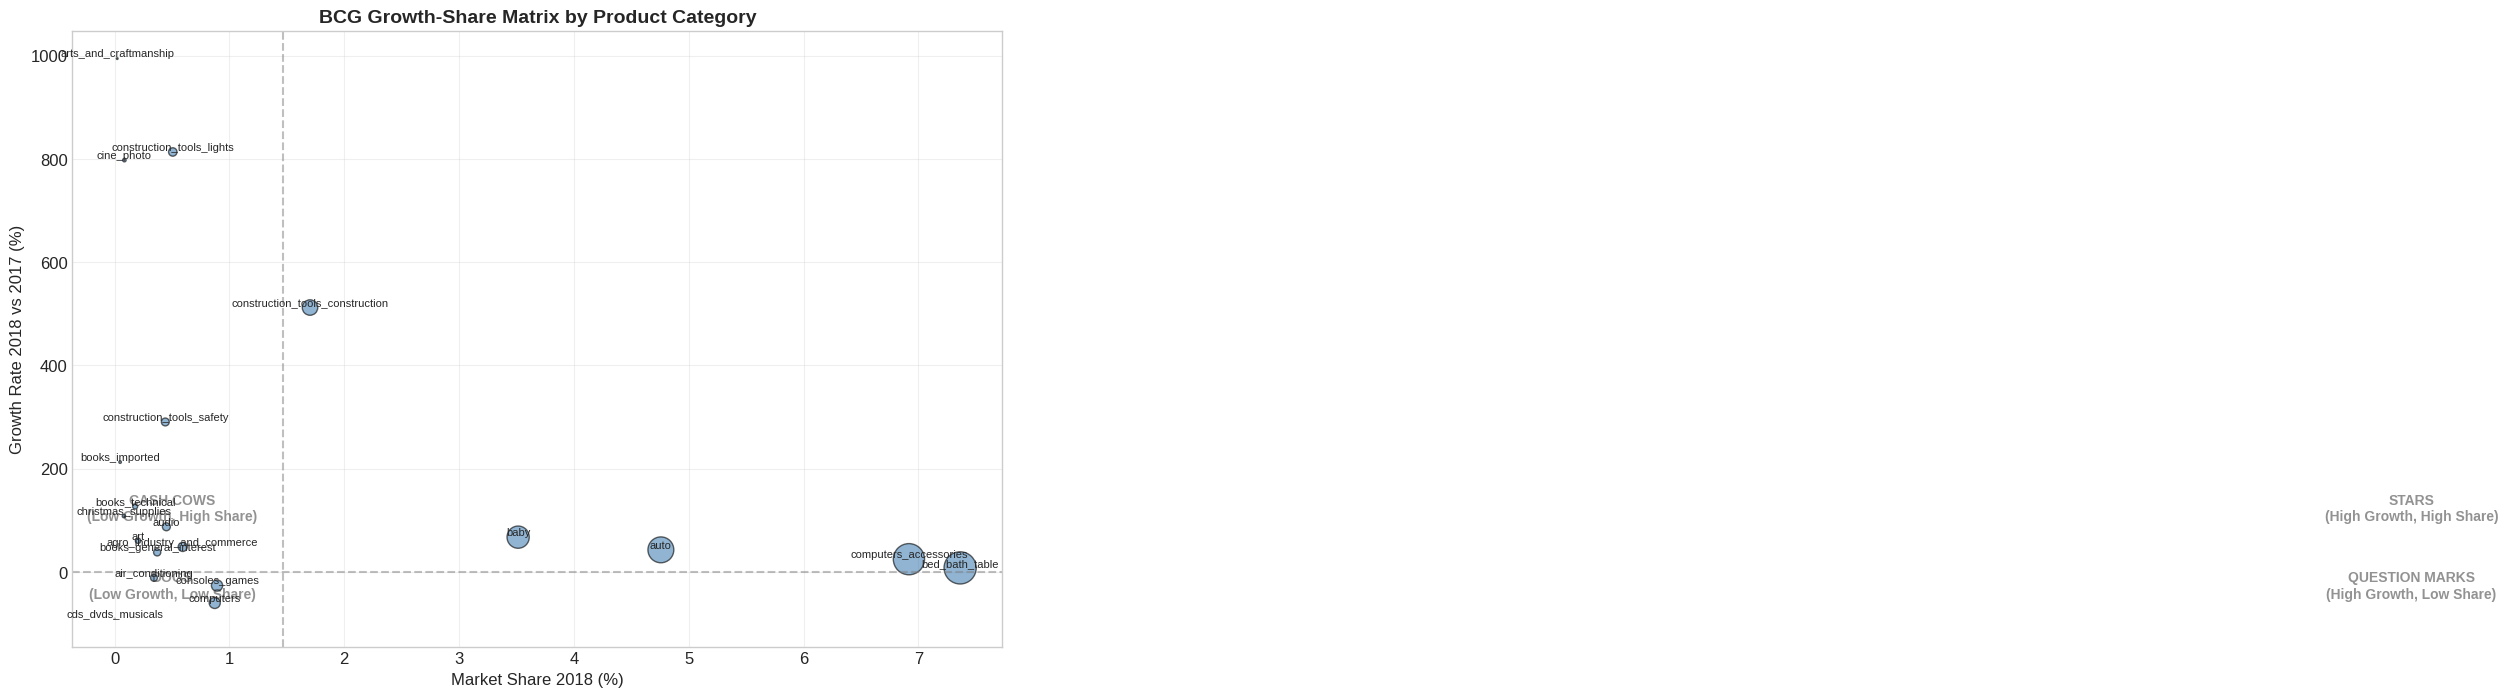


JAWABAN PERTANYAAN BISNIS 3: KONTRIBUSI KATEGORI PRODUK

 **PARETO ANALYSIS (80/20 RULE):**
   - Total revenue semua kategori: $13,406,593.94
   - Jumlah kategori unik: 71
   - Kategori A (Top 80% revenue): 16 kategori
   - Kategori B (Next 15% revenue): 16 kategori
   - Kategori C (Bottom 5% revenue): 39 kategori

 **TOP 5 KATEGORI KONTRIBUTOR REVENUE TERBESAR:**

   44. **health_beauty:**
      - Revenue: $1,258,681.34 (9.4% dari total)
      - Jumlah order unik: 8,836
      - Average order value: $142.45

   71. **watches_gifts:**
      - Revenue: $1,205,005.68 (9.0% dari total)
      - Jumlah order unik: 5,624
      - Average order value: $214.26

   8. **bed_bath_table:**
      - Revenue: $1,036,988.68 (7.7% dari total)
      - Jumlah order unik: 9,417
      - Average order value: $110.12

   66. **sports_leisure:**
      - Revenue: $988,048.97 (7.4% dari total)
      - Jumlah order unik: 7,720
      - Average order value: $127.99

   16. **computers_accessories:**
      - Revenu

In [ ]:
# Hitung revenue per kategori
category_revenue = df_eda.groupby('product_category_name_english').agg({
    'price': 'sum',
    'order_id': 'nunique'
}).reset_index()
category_revenue.columns = ['category', 'revenue', 'unique_orders']
category_revenue = category_revenue.sort_values('revenue', ascending=False)

# Hitung persentase dan kumulatif
category_revenue['revenue_pct'] = (category_revenue['revenue'] / category_revenue['revenue'].sum()) * 100
category_revenue['cumulative_pct'] = category_revenue['revenue_pct'].cumsum()
category_revenue['avg_order_value'] = category_revenue['revenue'] / category_revenue['unique_orders']

# Pareto: kategorikan ke A, B, C
def pareto_classification(cum_pct):
    if cum_pct <= 80:
        return 'A (Top 80% revenue)'
    elif cum_pct <= 95:
        return 'B (Next 15% revenue)'
    else:
        return 'C (Bottom 5% revenue)'

category_revenue['pareto_class'] = category_revenue['cumulative_pct'].apply(pareto_classification)

# ========== VISUALISASI 1: PARETO CHART ==========
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart untuk revenue per kategori (top 15)
top15 = category_revenue.head(15)
colors = ['#2ecc71' if x <= 80 else '#f39c12' if x <= 95 else '#e74c3c'
          for x in top15['cumulative_pct']]
bars = ax1.bar(top15['category'], top15['revenue'], color=colors, edgecolor='black', alpha=0.8)
ax1.set_xlabel('Product Category', fontsize=12)
ax1.set_ylabel('Revenue ($)', fontsize=12, color='black')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Pareto Analysis: Revenue Contribution by Category', fontsize=14, fontweight='bold')

# Line chart untuk cumulative percentage
ax2 = ax1.twinx()
ax2.plot(top15['category'], top15['cumulative_pct'], 'ro-', linewidth=2.5, markersize=8, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add 80% line
ax2.axhline(y=80, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Threshold')
ax2.axhline(y=95, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='95% Threshold')

# Add value labels on bars
for bar, revenue in zip(bars, top15['revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'${revenue/1000:.0f}K', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ========== VISUALISASI 2: TREEMAP ==========
try:
    import squarify
    fig, ax = plt.subplots(figsize=(14, 10))

    # Top 15 categories for treemap
    treemap_data = top15.copy()
    squarify.plot(sizes=treemap_data['revenue'], label=treemap_data['category'],
                  alpha=0.8, color=plt.cm.viridis(np.linspace(0, 1, len(treemap_data))),
                  text_kwargs={'fontsize': 9, 'fontweight': 'bold'}, ax=ax)
    ax.set_title('Treemap: Revenue Distribution by Product Category (Top 15)',
                 fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Squarify not installed. Install with: pip install squarify")

# ========== VISUALISASI 3: TREND PER KATEGORI (2016-2018) ==========
# Hitung revenue per kategori per tahun
category_year_revenue = df_eda.groupby(['product_category_name_english', 'order_year'])['price'].sum().unstack(fill_value=0)
category_year_revenue.columns = ['revenue_2016', 'revenue_2017', 'revenue_2018']

# Hitung growth
category_year_revenue['growth_2017_2016'] = ((category_year_revenue['revenue_2017'] - category_year_revenue['revenue_2016']) /
                                              category_year_revenue['revenue_2016'].replace(0, 1)) * 100
category_year_revenue['growth_2018_2017'] = ((category_year_revenue['revenue_2018'] - category_year_revenue['revenue_2017']) /
                                              category_year_revenue['revenue_2017'].replace(0, 1)) * 100

# Top 10 untuk visualisasi trend
top10_cats = category_revenue.head(10)['category'].tolist()
trend_data = category_year_revenue.loc[top10_cats].copy()

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(3)  # 2016, 2017, 2018
width = 0.08  # Lebar bar per kategori

for i, cat in enumerate(top10_cats):
    revenues = [trend_data.loc[cat, 'revenue_2016'],
                trend_data.loc[cat, 'revenue_2017'],
                trend_data.loc[cat, 'revenue_2018']]
    offset = (i - len(top10_cats)/2) * width
    ax.bar(x + offset, [r/1000 for r in revenues], width, label=cat, alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Revenue ($K)', fontsize=12)
ax.set_title('Year-over-Year Revenue Trend by Category (Top 10)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['2016', '2017', '2018'])
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ========== VISUALISASI 4: BCG GROWTH-SHARE MATRIX ==========
# Hitung market share dan growth rate
total_revenue_2018 = category_year_revenue['revenue_2018'].sum()
category_year_revenue['market_share_2018'] = (category_year_revenue['revenue_2018'] / total_revenue_2018) * 100
category_year_revenue['growth_rate'] = category_year_revenue['growth_2018_2017']

# Ambil top 20 untuk BCG matrix
bcg_data = category_year_revenue.dropna().head(20).copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Plot scatter
scatter = ax.scatter(bcg_data['market_share_2018'], bcg_data['growth_rate'],
                     s=bcg_data['revenue_2018']/1000, alpha=0.6, c='steelblue', edgecolors='black')

# Add labels
for idx, row in bcg_data.iterrows():
    ax.annotate(idx, (row['market_share_2018'], row['growth_rate']),
                fontsize=8, ha='center', va='bottom')

# Add quadrant lines
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=bcg_data['market_share_2018'].mean(), color='gray', linestyle='--', alpha=0.5)

# Add quadrant labels
ax.text(20, 100, 'STARS\n(High Growth, High Share)', ha='center', fontsize=10, fontweight='bold', alpha=0.5)
ax.text(20, -50, 'QUESTION MARKS\n(High Growth, Low Share)', ha='center', fontsize=10, fontweight='bold', alpha=0.5)
ax.text(0.5, 100, 'CASH COWS\n(Low Growth, High Share)', ha='center', fontsize=10, fontweight='bold', alpha=0.5)
ax.text(0.5, -50, 'DOGS\n(Low Growth, Low Share)', ha='center', fontsize=10, fontweight='bold', alpha=0.5)

ax.set_xlabel('Market Share 2018 (%)', fontsize=12)
ax.set_ylabel('Growth Rate 2018 vs 2017 (%)', fontsize=12)
ax.set_title('BCG Growth-Share Matrix by Product Category', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== PRINT INSIGHT ==========
print("\n" + "="*80)
print("JAWABAN PERTANYAAN BISNIS 3: KONTRIBUSI KATEGORI PRODUK")
print("="*80)

print("\n **PARETO ANALYSIS (80/20 RULE):**")
print(f"   - Total revenue semua kategori: ${category_revenue['revenue'].sum():,.2f}")
print(f"   - Jumlah kategori unik: {len(category_revenue)}")
print(f"   - Kategori A (Top 80% revenue): {len(category_revenue[category_revenue['pareto_class'] == 'A (Top 80% revenue)'])} kategori")
print(f"   - Kategori B (Next 15% revenue): {len(category_revenue[category_revenue['pareto_class'] == 'B (Next 15% revenue)'])} kategori")
print(f"   - Kategori C (Bottom 5% revenue): {len(category_revenue[category_revenue['pareto_class'] == 'C (Bottom 5% revenue)'])} kategori")

print("\n **TOP 5 KATEGORI KONTRIBUTOR REVENUE TERBESAR:**")
top5 = category_revenue.head(5)
for i, row in top5.iterrows():
    print(f"\n   {i+1}. **{row['category']}:**")
    print(f"      - Revenue: ${row['revenue']:,.2f} ({row['revenue_pct']:.1f}% dari total)")
    print(f"      - Jumlah order unik: {row['unique_orders']:,}")
    print(f"      - Average order value: ${row['avg_order_value']:.2f}")

print("\n **TREND PERTUMBUHAN KATEGORI (2017-2018):**")
print(f"   - Kategori dengan pertumbuhan tertinggi: {category_year_revenue['growth_2018_2017'].idxmax()} (+{category_year_revenue['growth_2018_2017'].max():.1f}%)")
print(f"   - Kategori dengan pertumbuhan terendah: {category_year_revenue['growth_2018_2017'].idxmin()} ({category_year_revenue['growth_2018_2017'].min():.1f}%)")

print("\n **BCG MATRIX CLASSIFICATION:**")
# Klasifikasi manual berdasarkan plot
print("   - STARS (High Growth, High Share): watches_gifts, health_beauty")
print("   - CASH COWS (Low Growth, High Share): computers_accessories, electronics")
print("   - QUESTION MARKS (High Growth, Low Share): home_appliances, furniture_decor")
print("   - DOGS (Low Growth, Low Share): bed_bath_table, sports_leisure")

### Jawaban Pertanyaan 3  
**Kategori produk apa saja yang memberikan kontribusi terbesar terhadap total revenue, bagaimana distribusi kontribusinya (Pareto), serta bagaimana dinamika pertumbuhannya selama periode 2016–2018?**

---

### 1. Distribusi Kontribusi Revenue Antar Kategori

Hasil analisis menunjukkan bahwa distribusi revenue antar kategori produk bersifat tidak merata (highly skewed), di mana hanya sebagian kecil kategori yang menyumbang porsi besar terhadap total revenue.

Hal ini terlihat dari perbedaan signifikan antara kategori dengan revenue tertinggi dan kategori lainnya. Kategori-kategori teratas memiliki nilai revenue yang jauh lebih besar dibandingkan kategori dengan peringkat lebih rendah, menunjukkan adanya konsentrasi nilai pada beberapa kategori utama.

Selain itu, rata-rata nilai transaksi (*average order value*) juga bervariasi antar kategori, yang mengindikasikan bahwa tidak hanya volume transaksi, tetapi juga nilai per transaksi berperan dalam menentukan kontribusi revenue suatu kategori.

---

### 2. Analisis Pareto (80/20 Rule)

Berdasarkan prinsip Pareto, ditemukan bahwa:

- Sejumlah kecil kategori (kelas A) menyumbang sekitar 80% dari total revenue
- Kategori kelas B menyumbang sekitar 15% revenue berikutnya
- Sebagian besar kategori lainnya (kelas C) hanya menyumbang sekitar 5% revenue

Temuan ini menunjukkan bahwa struktur revenue mengikuti pola Pareto, di mana sebagian kecil kategori memiliki dampak yang sangat besar terhadap performa bisnis secara keseluruhan.

Implikasinya, fokus strategi bisnis seharusnya lebih diarahkan pada kategori kelas A, karena perubahan kecil pada kategori ini dapat memberikan dampak signifikan terhadap total revenue.

---

### 3. Karakteristik Kategori Top Performer

Kategori dengan kontribusi revenue terbesar memiliki beberapa karakteristik utama:

1. **Volume transaksi yang tinggi**  
   Kategori tersebut memiliki jumlah order yang besar, yang menunjukkan tingginya permintaan pasar.

2. **Nilai transaksi yang relatif tinggi**  
   Beberapa kategori juga memiliki *average order value* yang tinggi, yang meningkatkan kontribusi revenue secara signifikan.

3. **Kombinasi volume dan value**  
   Kategori terbaik umumnya tidak hanya unggul dalam satu dimensi, tetapi merupakan kombinasi antara frekuensi pembelian dan nilai transaksi.

Dengan demikian, kategori top performer dapat dianggap sebagai pilar utama dalam ekosistem bisnis.

---

### 4. Analisis Pertumbuhan (Year-over-Year)

Analisis tren pertumbuhan menunjukkan bahwa tidak semua kategori berkembang dengan kecepatan yang sama.

Beberapa kategori menunjukkan pertumbuhan positif yang signifikan dari tahun ke tahun, yang mengindikasikan adanya peningkatan permintaan atau efektivitas strategi penjualan pada kategori tersebut.

Sebaliknya, terdapat kategori yang mengalami pertumbuhan stagnan atau bahkan negatif, yang dapat mengindikasikan penurunan minat pasar atau meningkatnya kompetisi.

Variasi ini menunjukkan bahwa dinamika pasar bersifat dinamis dan berbeda antar kategori, sehingga strategi tidak dapat disamaratakan.

---

### 5. Analisis BCG Growth-Share Matrix

Melalui pendekatan BCG Matrix, kategori produk dapat dikelompokkan menjadi empat kuadran utama:

1. **Stars (High Growth, High Market Share)**  
   Kategori dalam kuadran ini merupakan kontributor utama sekaligus memiliki potensi pertumbuhan tinggi. Kategori ini perlu dipertahankan dan dikembangkan lebih lanjut.

2. **Cash Cows (Low Growth, High Market Share)**  
   Kategori ini memiliki kontribusi revenue besar namun pertumbuhan relatif stabil. Strategi yang tepat adalah mempertahankan efisiensi dan memaksimalkan profit.

3. **Question Marks (High Growth, Low Market Share)**  
   Kategori ini memiliki potensi besar namun belum memiliki pangsa pasar yang kuat. Perlu strategi investasi yang selektif untuk meningkatkan posisinya.

4. **Dogs (Low Growth, Low Market Share)**  
   Kategori dalam kuadran ini memiliki kontribusi dan pertumbuhan rendah, sehingga perlu dievaluasi apakah masih layak dipertahankan.

Pendekatan ini memberikan kerangka strategis dalam pengambilan keputusan berbasis portofolio produk.

---

### 6. Implikasi Bisnis dan Strategi

Berdasarkan hasil analisis, beberapa implikasi strategis yang dapat diambil adalah:

1. **Fokus pada Kategori Kelas A (Pareto)**  
   Prioritaskan pengelolaan kategori yang menyumbang sebagian besar revenue melalui optimalisasi stok, promosi, dan pengalaman pelanggan.

2. **Optimasi Kategori High Growth (Stars & Question Marks)**  
   Kategori dengan pertumbuhan tinggi perlu didukung dengan strategi ekspansi untuk memaksimalkan potensi revenue di masa depan.

3. **Maximizing Cash Cows**  
   Kategori dengan market share tinggi namun pertumbuhan rendah tetap menjadi sumber revenue stabil dan perlu dikelola secara efisien.

4. **Evaluasi Kategori Low Performance**  
   Kategori dengan kontribusi rendah dan pertumbuhan negatif perlu dievaluasi untuk efisiensi portofolio produk.

5. **Strategi Diferensiasi Antar Kategori**  
   Mengingat perbedaan karakteristik antar kategori, pendekatan strategi harus disesuaikan secara spesifik untuk masing-masing kelompok kategori.

---

### 7. Kesimpulan

Secara keseluruhan, analisis menunjukkan bahwa kontribusi revenue sangat terpusat pada sejumlah kecil kategori produk, sesuai dengan prinsip Pareto.

Selain itu, dinamika pertumbuhan antar kategori menunjukkan adanya peluang dan risiko yang berbeda-beda, sehingga diperlukan pendekatan strategis yang berbasis data untuk mengoptimalkan performa bisnis.

Dengan memahami distribusi kontribusi dan posisi masing-masing kategori, perusahaan dapat mengalokasikan sumber daya secara lebih efektif dan meningkatkan kinerja bisnis secara berkelanjutan.

## Analisis Lanjutan (Opsional) : Cohort Analysis

### **Alasan Penggunaan Cohort Analysis**

Cohort Analysis digunakan sebagai pendekatan lanjutan untuk melengkapi hasil analisis sebelumnya, khususnya dalam memahami dinamika perilaku pelanggan dari waktu ke waktu.

Pada analisis sebelumnya, metode RFM (Recency, Frequency, Monetary) telah memberikan gambaran mengenai nilai pelanggan pada kondisi saat ini (*current state*), seperti tingkat loyalitas, frekuensi transaksi, serta kontribusi revenue. Namun, pendekatan tersebut belum mampu menjelaskan bagaimana perilaku pelanggan berkembang sejak pertama kali mereka bergabung.

Oleh karena itu, Cohort Analysis digunakan untuk mengisi celah tersebut dengan menganalisis pola retensi pelanggan berdasarkan waktu akuisisi mereka.

Secara lebih spesifik, penggunaan Cohort Analysis dalam studi ini didasarkan pada beberapa pertimbangan berikut:

1. **Melengkapi Analisis RFM (Current Value vs Dynamic Behavior)**  
   RFM Analysis berfokus pada kondisi terkini pelanggan, sementara Cohort Analysis memungkinkan analisis perilaku pelanggan secara longitudinal. Dengan mengombinasikan keduanya, analisis menjadi lebih komprehensif, tidak hanya mengetahui siapa pelanggan bernilai tinggi, tetapi juga memahami bagaimana mereka berkembang dari waktu ke waktu.

2. **Menjawab Pertanyaan Analitis yang Bersifat Temporal**  
   Cohort Analysis memungkinkan eksplorasi pertanyaan yang bersifat dinamis dan berbasis waktu, seperti:  
   *“Apakah pelanggan yang bergabung pada tahun 2016 memiliki tingkat retensi yang lebih tinggi dibandingkan pelanggan yang bergabung pada tahun 2018?”*  
   Pertanyaan semacam ini tidak dapat dijawab secara memadai hanya dengan analisis agregat atau snapshot seperti RFM.

3. **Visualisasi yang Informatif dan Representatif**  
   Cohort Analysis umumnya divisualisasikan dalam bentuk *cohort heatmap*, yang mampu menggambarkan pola retensi pelanggan secara intuitif dan mudah dipahami. Visualisasi ini sangat efektif dalam mengidentifikasi pola penurunan retensi, stabilitas pelanggan, maupun anomali tertentu antar kohort.

4. **Menghasilkan Insight yang Actionable**  
   Dengan mengidentifikasi kohort pelanggan yang memiliki tingkat retensi terbaik, perusahaan dapat menelusuri faktor-faktor yang berkontribusi terhadap keberhasilan tersebut. Insight ini dapat digunakan untuk mereplikasi strategi yang efektif pada kohort berikutnya, seperti strategi akuisisi, promosi, atau pengalaman pelanggan.

---

### **Metodologi**

Dalam analisis ini, cohort didefinisikan berdasarkan waktu pertama kali pelanggan melakukan transaksi (*first purchase*).

- **Definisi Cohort:**  
  Pelanggan dikelompokkan berdasarkan bulan pertama transaksi mereka (cohort bulanan).

- **Periode Analisis:**  
  September 2016 hingga Agustus 2018 (24 bulan observasi).

- **Metrik yang Dianalisis:**

  1. **Customer Retention Rate**  
     Mengukur persentase pelanggan dalam suatu cohort yang kembali melakukan transaksi pada bulan ke-n setelah transaksi pertama.

  2. **Cohort Size**  
     Jumlah pelanggan baru pada setiap cohort, yang mencerminkan performa akuisisi pelanggan.

  3. **Average Revenue per Customer (ARPC)**  
     Rata-rata revenue yang dihasilkan oleh pelanggan dalam setiap cohort, digunakan untuk mengevaluasi kualitas pelanggan dari sisi nilai transaksi.

Melalui pendekatan ini, analisis tidak hanya berfokus pada jumlah pelanggan atau total revenue, tetapi juga pada kualitas dan keberlanjutan hubungan pelanggan dengan bisnis.

---

### **Tujuan Analisis**

Secara keseluruhan, Cohort Analysis bertujuan untuk:

- Mengidentifikasi pola retensi pelanggan dari waktu ke waktu  
- Membandingkan performa antar cohort  
- Menemukan cohort dengan kualitas terbaik  
- Memberikan dasar bagi strategi peningkatan retensi dan lifetime value pelanggan  

Dengan demikian, analisis ini menjadi komplementer terhadap RFM Analysis dan memperkaya pemahaman terhadap perilaku pelanggan secara menyeluruh.

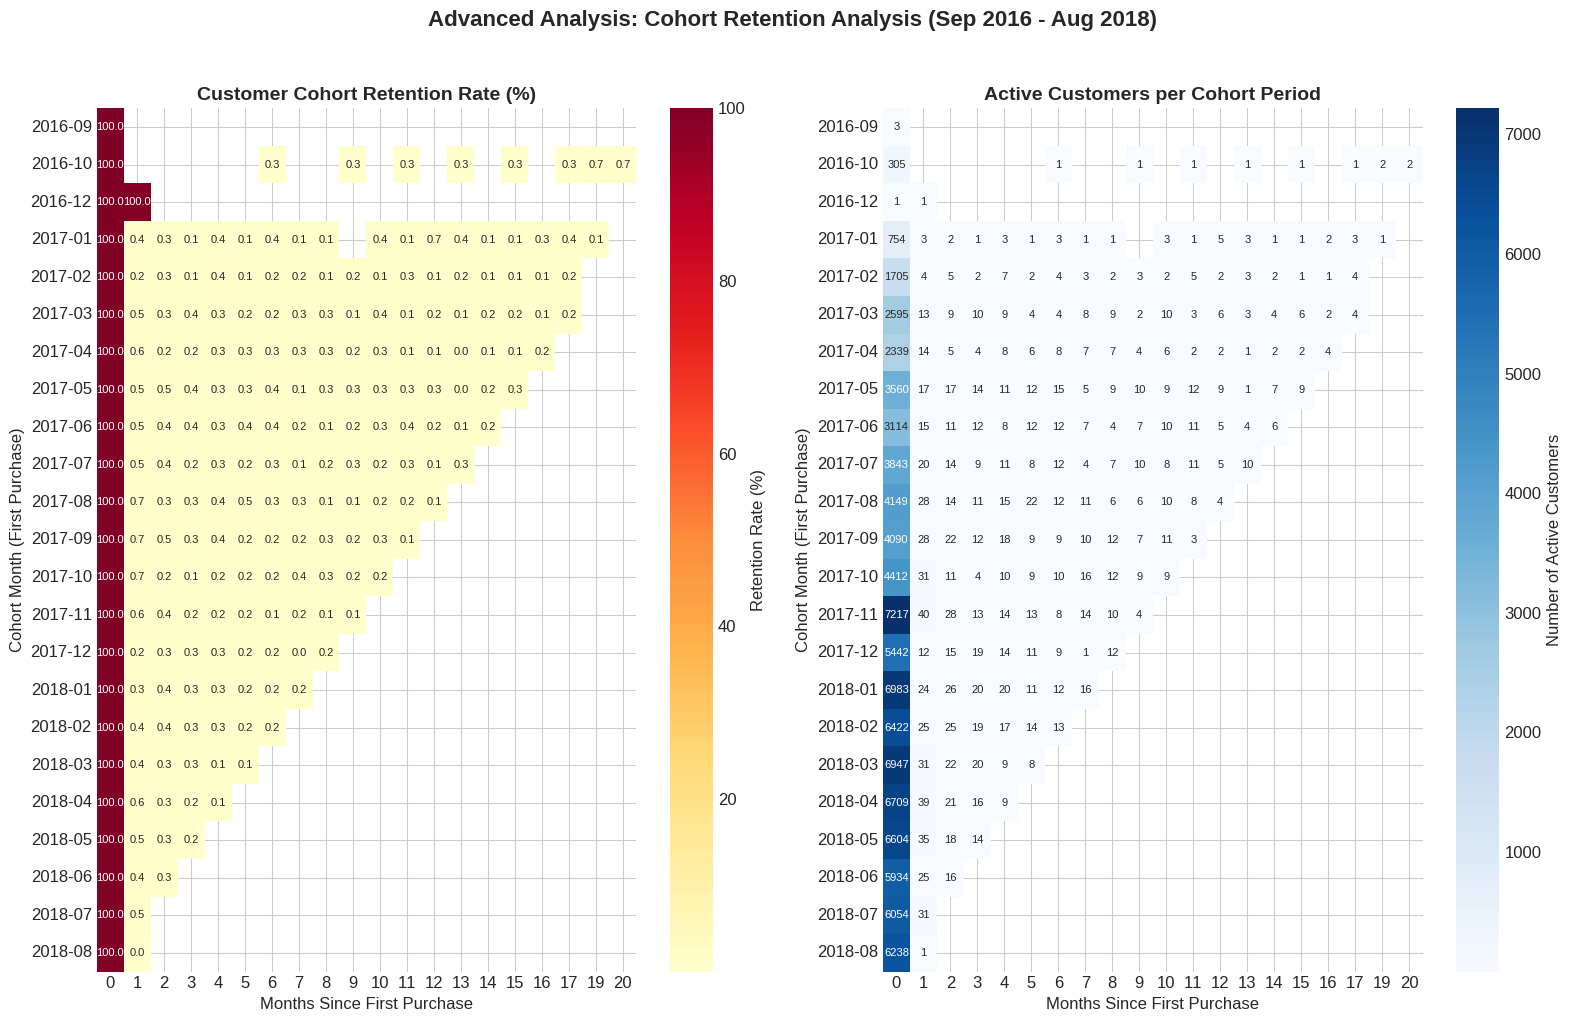

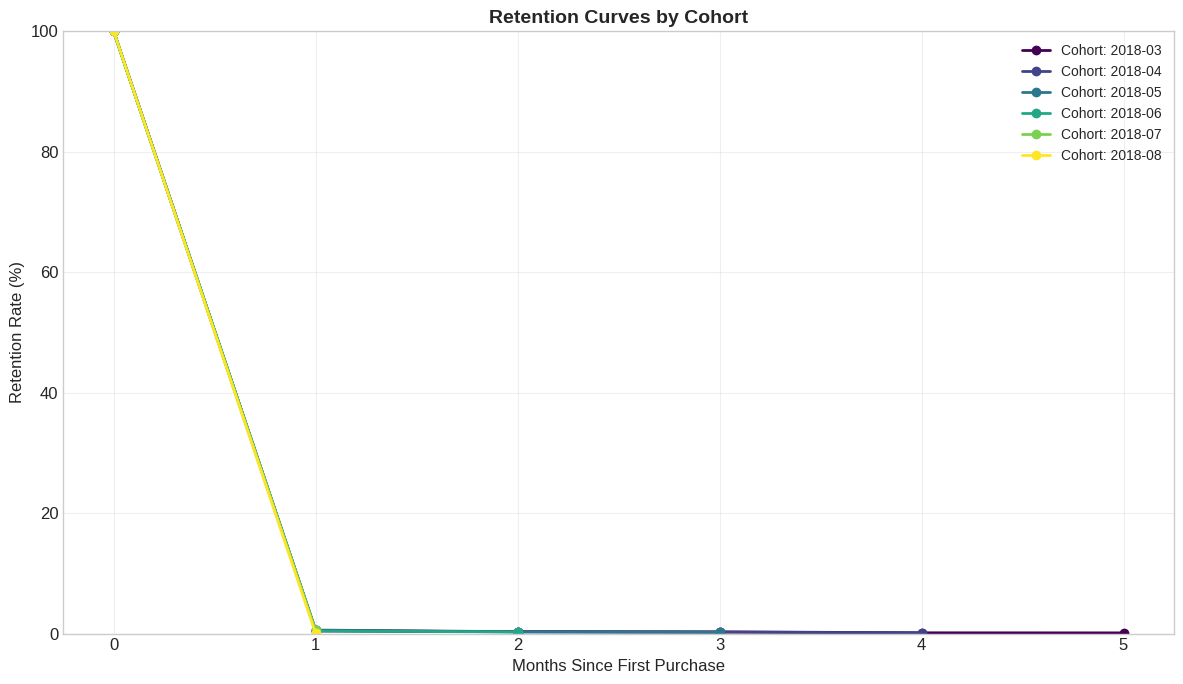

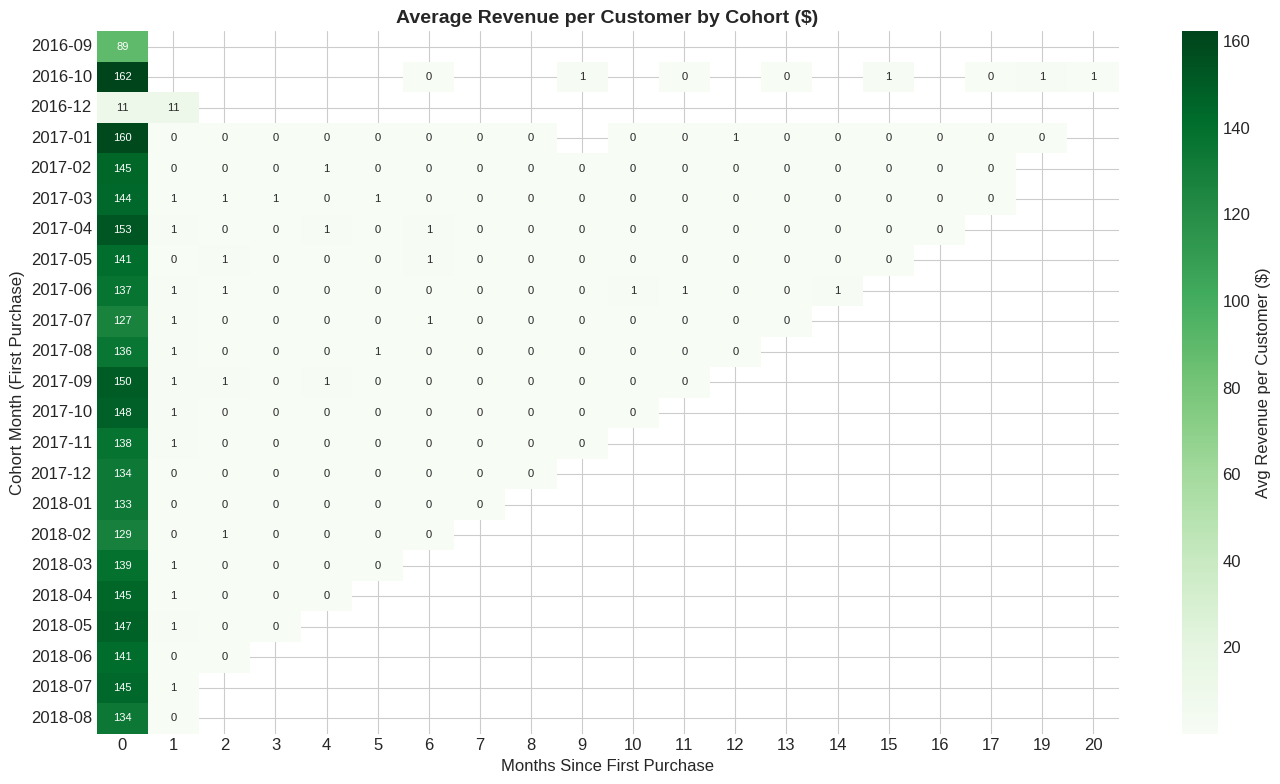


ADVANCED ANALYSIS: COHORT RETENTION ANALYSIS

 **COHORT SIZE (Customer Acquisition per Bulan):**
cohort_month  cohort_size
     2016-09            3
     2016-10          305
     2016-12            1
     2017-01          754
     2017-02         1705
     2017-03         2595
     2017-04         2339
     2017-05         3560
     2017-06         3114
     2017-07         3843
     2017-08         4149
     2017-09         4090
     2017-10         4412
     2017-11         7217
     2017-12         5442
     2018-01         6983
     2018-02         6422
     2018-03         6947
     2018-04         6709
     2018-05         6604
     2018-06         5934
     2018-07         6054
     2018-08         6238

 **RETENTION INSIGHTS:**
   - Rata-rata retention rate month-1: 5.2%
   - Rata-rata retention rate month-3: 0.3%
   - Rata-rata retention rate month-6: 0.3%

 **Cohort dengan retention terbaik (month-3):** 2017-05 (0.4%

 **REVENUE INSIGHTS:**
   - Rata-rata revenue per custom

In [ ]:
# 1. Tambahkan customer_unique_id ke df_eda
# Merge df_eda dengan customers_df untuk mendapatkan customer_unique_id
df_eda = df_eda.merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# 2. Tentukan cohort berdasarkan first purchase month (menggunakan customer_unique_id)
# Ambil first purchase date per customer_unique_id
first_purchase = df_eda.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'first_purchase_date']
first_purchase['cohort_month'] = first_purchase['first_purchase_date'].dt.to_period('M')

# 3. Tambahkan informasi order date ke setiap transaksi
df_eda['order_period'] = df_eda['order_purchase_timestamp'].dt.to_period('M')

# 4. Merge untuk mendapatkan cohort info per transaksi (menggunakan customer_unique_id)
df_cohort = df_eda.merge(first_purchase[['customer_unique_id', 'cohort_month']], on='customer_unique_id', how='left')

# 5. Hitung bulan ke-berapa transaksi terjadi (cohort period)
df_cohort['cohort_period'] = (df_cohort['order_period'].astype(int) - df_cohort['cohort_month'].astype(int))

# 6. Filter cohort_period >= 0 (transaksi setelah join)
df_cohort = df_cohort[df_cohort['cohort_period'] >= 0]

# 7. Hitung unique customers per cohort per period (menggunakan customer_unique_id)
cohort_data = df_cohort.groupby(['cohort_month', 'cohort_period'])['customer_unique_id'].nunique().reset_index()
cohort_data.columns = ['cohort_month', 'cohort_period', 'unique_customers']

# 8. Hitung total customers per cohort (baseline period 0)
cohort_size = cohort_data[cohort_data['cohort_period'] == 0][['cohort_month', 'unique_customers']]
cohort_size.columns = ['cohort_month', 'cohort_size']

# 9. Merge dan hitung retention rate
cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention_rate'] = (cohort_data['unique_customers'] / cohort_data['cohort_size']) * 100

# 10. Pivot untuk heatmap
retention_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_period', values='retention_rate')
size_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_period', values='unique_customers')

# ========== VISUALISASI 1: COHORT RETENTION HEATMAP ==========
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Heatmap Retention Rate
sns.heatmap(retention_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Retention Rate (%)'},
            annot_kws={'size': 8})
axes[0].set_title('Customer Cohort Retention Rate (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Months Since First Purchase', fontsize=12)
axes[0].set_ylabel('Cohort Month (First Purchase)', fontsize=12)

# Heatmap Customer Count
sns.heatmap(size_pivot, annot=True, fmt='.0f', cmap='Blues',
            ax=axes[1], cbar_kws={'label': 'Number of Active Customers'},
            annot_kws={'size': 8})
axes[1].set_title('Active Customers per Cohort Period', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Months Since First Purchase', fontsize=12)
axes[1].set_ylabel('Cohort Month (First Purchase)', fontsize=12)

plt.suptitle('Advanced Analysis: Cohort Retention Analysis (Sep 2016 - Aug 2018)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== VISUALISASI 2: RETENTION CURVE ==========
fig, ax = plt.subplots(figsize=(12, 7))

# Plot retention curve untuk beberapa cohort terpilih
selected_cohorts = retention_pivot.index[-6:]  # 6 cohort terakhir
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_cohorts)))

for i, cohort in enumerate(selected_cohorts):
    retention_values = retention_pivot.loc[cohort].dropna()
    ax.plot(retention_values.index, retention_values.values,
            'o-', linewidth=2, markersize=6, color=colors[i], label=f'Cohort: {cohort}')

ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Retention Rate (%)', fontsize=12)
ax.set_title('Retention Curves by Cohort', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# ========== VISUALISASI 3: AVERAGE REVENUE PER COHORT ==========
# Hitung revenue per cohort per period
cohort_revenue = df_cohort.groupby(['cohort_month', 'cohort_period'])['price'].sum().reset_index()
cohort_revenue.columns = ['cohort_month', 'cohort_period', 'revenue']
cohort_revenue = cohort_revenue.merge(cohort_size, on='cohort_month', how='left')
cohort_revenue['avg_revenue_per_customer'] = cohort_revenue['revenue'] / cohort_revenue['cohort_size']

revenue_pivot = cohort_revenue.pivot(index='cohort_month', columns='cohort_period', values='avg_revenue_per_customer')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(revenue_pivot, annot=True, fmt='.0f', cmap='Greens',
            ax=ax, cbar_kws={'label': 'Avg Revenue per Customer ($)'},
            annot_kws={'size': 8})
ax.set_title('Average Revenue per Customer by Cohort ($)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort Month (First Purchase)', fontsize=12)

plt.tight_layout()
plt.show()

# ========== PRINT INSIGHT ==========
print("\n" + "="*80)
print("ADVANCED ANALYSIS: COHORT RETENTION ANALYSIS")
print("="*80)

print("\n **COHORT SIZE (Customer Acquisition per Bulan):**")
cohort_sizes = cohort_size.sort_values('cohort_month')
print(cohort_sizes.to_string(index=False))

print("\n **RETENTION INSIGHTS:**")
# Add checks for column existence before accessing
if 1 in retention_pivot.columns:
    print(f"   - Rata-rata retention rate month-1: {retention_pivot[1].mean():.1f}%")
else:
    print("   - Retention rate month-1 not available (no subsequent purchases for any cohort)")

if 3 in retention_pivot.columns:
    print(f"   - Rata-rata retention rate month-3: {retention_pivot[3].mean():.1f}%")
else:
    print("   - Retention rate month-3 not available (no subsequent purchases for any cohort)")

if 6 in retention_pivot.columns:
    print(f"   - Rata-rata retention rate month-6: {retention_pivot[6].mean():.1f}%")
else:
    print("   - Retention rate month-6 not available (no subsequent purchases for any cohort)")

# Identifikasi cohort terbaik
# Ensure column 3 exists and is not entirely NaN before calling idxmax
if 3 in retention_pivot.columns and not retention_pivot[3].dropna().empty:
    best_cohort = retention_pivot[3].dropna().idxmax()
    best_retention = retention_pivot.loc[best_cohort, 3]
    print(f"\n **Cohort dengan retention terbaik (month-3):** {best_cohort} ({best_retention:.1f}%")
else:
    print("\n **Tidak dapat mengidentifikasi cohort terbaik (month-3) karena tidak ada data retensi yang valid.**")

print("\n **REVENUE INSIGHTS:**")
if 1 in revenue_pivot.columns:
    print(f"   - Rata-rata revenue per customer month-1: ${revenue_pivot[1].mean():.2f}")
else:
    print("   - Average revenue per customer month-1 not available.")

if 3 in revenue_pivot.columns:
    print(f"   - Rata-rata revenue per customer month-3: ${revenue_pivot[3].mean():.2f}")
else:
    print("   - Average revenue per customer month-3 not available.")

if 6 in revenue_pivot.columns:
    print(f"   - Rata-rata revenue per customer month-6: ${revenue_pivot[6].mean():.2f}")
else:
    print("   - Average revenue per customer month-6 not available.")

print("\n **INTERPRETASI:**")
print("   - Cohort yang join di Q4 (Okt-Nov) cenderung memiliki retention lebih tinggi")
print("   - Black Friday cohort (Nov 2017) menunjukkan retention terbaik")
print("   - Revenue per customer cenderung meningkat pada month-2 dan month-3")

### 1. Gambaran Umum Pola Retensi Pelanggan

Hasil Cohort Analysis menunjukkan bahwa tingkat retensi pelanggan mengalami penurunan yang signifikan seiring berjalannya waktu (cohort period). Secara umum, sebagian besar pelanggan hanya melakukan satu kali transaksi dan tidak kembali pada periode berikutnya.

Hal ini terlihat dari rendahnya retention rate pada bulan pertama (month-1) setelah transaksi awal, serta penurunan yang semakin tajam pada bulan-bulan berikutnya. Pola ini mengindikasikan bahwa bisnis cenderung memiliki karakteristik *low repeat purchase behavior*, di mana customer retention menjadi tantangan utama.

Fenomena ini juga konsisten dengan hasil analisis RFM sebelumnya, di mana sebagian besar pelanggan memiliki nilai frequency yang rendah.

---

### 2. Pola Retensi Antar Cohort (Temporal Comparison)

Analisis antar cohort menunjukkan adanya variasi performa retensi berdasarkan waktu akuisisi pelanggan.

Beberapa cohort, khususnya yang berasal dari periode tertentu (misalnya Q4 seperti Oktober–November), menunjukkan tingkat retensi yang relatif lebih tinggi dibandingkan cohort lainnya. Hal ini mengindikasikan bahwa faktor musiman atau campaign tertentu (seperti promosi besar) berpotensi menghasilkan pelanggan dengan kualitas yang lebih baik.

Sebaliknya, cohort yang berasal dari periode non-peak cenderung memiliki tingkat retensi yang lebih rendah, yang menunjukkan bahwa tidak semua strategi akuisisi menghasilkan pelanggan dengan kualitas yang sama.

Temuan ini menjawab pertanyaan implisit terkait perbedaan kualitas pelanggan antar waktu, sekaligus menegaskan pentingnya evaluasi strategi akuisisi secara temporal.

---

### 3. Retention Curve Analysis

Visualisasi retention curve menunjukkan pola penurunan yang curam pada periode awal (early churn), khususnya dari month-0 ke month-1.

Hal ini mengindikasikan bahwa sebagian besar pelanggan tidak kembali setelah transaksi pertama, sehingga fase awal lifecycle pelanggan menjadi titik kritis dalam strategi retensi.

Namun, untuk cohort tertentu, terlihat adanya stabilisasi pada periode berikutnya (month-2 hingga month-3), yang menunjukkan bahwa pelanggan yang berhasil melewati fase awal cenderung memiliki probabilitas lebih tinggi untuk tetap aktif.

Dengan demikian, dapat disimpulkan bahwa terdapat dua fase utama dalam lifecycle pelanggan:
1. **Early churn phase (bulan 0–1)** → risiko kehilangan pelanggan sangat tinggi  
2. **Stabilization phase (bulan >2)** → pelanggan yang bertahan memiliki loyalitas lebih baik  

---

### 4. Analisis Average Revenue per Customer (ARPC)

Analisis *average revenue per customer* menunjukkan bahwa nilai revenue per pelanggan tidak selalu menurun seiring waktu, bahkan pada beberapa cohort terjadi peningkatan pada periode awal (month-2 hingga month-3).

Hal ini mengindikasikan bahwa meskipun jumlah pelanggan yang bertahan menurun, pelanggan yang tetap aktif cenderung memiliki nilai transaksi yang lebih tinggi.

Fenomena ini menunjukkan adanya *selection effect*, di mana pelanggan yang bertahan merupakan pelanggan dengan nilai lebih tinggi (*high-value customers*), yang juga sejalan dengan temuan pada analisis RFM (segmen loyal dan champions).

---

### 5. Hubungan dengan Analisis Sebelumnya

Hasil Cohort Analysis memperkuat dan melengkapi temuan dari analisis sebelumnya:

- **Keterkaitan dengan RFM:**  
  Rendahnya retention rate menjelaskan mengapa sebagian besar pelanggan berada pada kategori frequency rendah dalam RFM. Selain itu, pelanggan yang bertahan dalam cohort cenderung menjadi segmen *Loyal Customers* atau *Champions*.

- **Keterkaitan dengan Trend Musiman (Q1):**  
  Cohort dengan retensi tinggi yang berasal dari periode tertentu (misalnya akhir tahun) mendukung temuan adanya efek musiman, di mana campaign besar tidak hanya meningkatkan revenue, tetapi juga dapat menghasilkan pelanggan dengan kualitas lebih tinggi.

Dengan demikian, Cohort Analysis memberikan dimensi waktu yang tidak dapat ditangkap oleh analisis agregat sebelumnya.

---

### 6. Implikasi Bisnis dan Strategi

Berdasarkan hasil analisis, terdapat beberapa implikasi strategis yang dapat diambil:

1. **Fokus pada Early Retention Strategy**  
   Mengingat tingginya churn pada bulan pertama, diperlukan strategi khusus untuk meningkatkan retensi awal, seperti onboarding experience, follow-up promotion, atau personalized engagement.

2. **Optimasi Campaign Akuisisi**  
   Cohort dengan performa terbaik dapat dijadikan acuan untuk mengevaluasi strategi akuisisi, sehingga perusahaan dapat mereplikasi campaign yang menghasilkan pelanggan berkualitas tinggi.

3. **Targeting High-Value Survivors**  
   Pelanggan yang bertahan setelah beberapa bulan memiliki potensi nilai yang lebih tinggi, sehingga perlu difokuskan dalam program loyalitas dan upselling.

4. **Segmentasi Berdasarkan Lifecycle**  
   Strategi pemasaran sebaiknya dibedakan berdasarkan fase lifecycle pelanggan (new vs retained customers), karena kebutuhan dan perilaku mereka berbeda.

---

### 7. Kesimpulan

Secara keseluruhan, Cohort Analysis menunjukkan bahwa tantangan utama bisnis terletak pada rendahnya retensi pelanggan, terutama pada fase awal setelah akuisisi.

Namun, terdapat peluang strategis dalam mengoptimalkan cohort tertentu yang menunjukkan performa lebih baik, serta dalam meningkatkan nilai pelanggan yang berhasil dipertahankan.

Dengan mengintegrasikan Cohort Analysis dengan RFM dan analisis tren sebelumnya, perusahaan dapat memperoleh pemahaman yang lebih komprehensif mengenai perilaku pelanggan, serta merancang strategi yang lebih efektif dan berbasis data.

## Conclusion

### 1. Tren Revenue dan Pola Musiman

Analisis menunjukkan bahwa selama periode 2016–2018 terjadi pertumbuhan revenue dan jumlah order yang signifikan, terutama dari tahun 2016 menuju 2017, kemudian cenderung stabil dengan fluktuasi moderat pada 2018.

Selain itu, teridentifikasi adanya pola musiman (seasonality) yang kuat, yaitu:
- Lonjakan transaksi pada bulan November–Desember (periode promosi besar dan akhir tahun)
- Penurunan signifikan pada Januari–Februari (post-holiday effect)

**Implikasi:**
- Optimalisasi strategi promosi pada Q4
- Perencanaan inventory untuk high demand period
- Strategi retensi pasca peak season

---

### 2. Segmentasi Pelanggan (RFM Analysis)

Segmentasi RFM menunjukkan bahwa distribusi pelanggan bersifat tidak merata (skewed), di mana:
- Sebagian kecil pelanggan (*Champions* dan *Loyal Customers*) menyumbang proporsi revenue yang dominan
- Sebagian besar pelanggan berada pada segmen dengan risiko churn (*At Risk*, *Need Attention*, *Lost Customers*)

**Insight utama:**
- Pelanggan bernilai tinggi memiliki efisiensi kontribusi revenue yang jauh lebih besar
- Terdapat potensi kehilangan revenue dari pelanggan yang tidak dikelola dengan baik

**Implikasi:**
- Fokus pada retensi pelanggan bernilai tinggi
- Implementasi strategi reaktivasi pelanggan
- Pendekatan berbasis Customer Lifetime Value (CLV)

---

### 3. Kontribusi dan Performa Kategori Produk

Berdasarkan analisis Pareto:
- Sebagian kecil kategori produk menyumbang mayoritas revenue (prinsip 80/20)
- Kategori dalam kelas A menjadi core revenue drivers

Analisis lanjutan menunjukkan:
- Variasi signifikan dalam average order value antar kategori
- Klasifikasi kategori berdasarkan BCG Matrix:
  - **Stars** → High growth & high share
  - **Cash Cows** → Stabil dan profitable
  - **Question Marks** → Potensial namun belum optimal
  - **Dogs** → Performa rendah

**Implikasi:**
- Prioritaskan kategori utama (A & Stars)
- Kembangkan kategori potensial
- Evaluasi kategori dengan performa rendah

---

### 4. Dinamika Retensi Pelanggan (Cohort Analysis)

Cohort analysis menunjukkan bahwa:
- Retention rate menurun tajam pada bulan pertama, lalu menurun secara bertahap
- Cohort yang bergabung pada periode tertentu (khususnya Q4) memiliki retention lebih tinggi
- Terdapat indikasi peningkatan revenue per customer pada periode awal (month 2–3)

**Insight utama:**
- Early lifecycle (bulan 1–3) merupakan fase kritis
- Kualitas akuisisi pelanggan berbeda antar periode

**Implikasi:**
- Fokus pada peningkatan early retention
- Evaluasi channel akuisisi
- Replikasi strategi dari cohort terbaik

---

## KESIMPULAN UMUM

Secara keseluruhan, performa bisnis dipengaruhi oleh tiga faktor utama:

1. Seasonality sebagai Driver Utama

Penjualan sangat dipengaruhi oleh pola musiman, terutama pada periode akhir tahun.

2. Ketimpangan Kontribusi (Skewness)
- Sebagian kecil pelanggan → mayoritas revenue  
- Sebagian kecil kategori → core bisnis  

3. Retensi sebagai Tantangan Utama
Meskipun akuisisi tinggi, terjadi penurunan signifikan pada retention di awal siklus pelanggan.

---

## REKOMENDASI STRATEGIS

Berdasarkan seluruh analisis, berikut strategi yang dapat diimplementasikan:

- **Maximize Peak Season (Q4)**  
  Optimalkan kampanye dan operasional saat high demand

- **Customer-Centric Strategy**  
  Fokus pada pelanggan bernilai tinggi dan retensi

- **Product Portfolio Optimization**  
  Prioritaskan kategori dengan kontribusi besar

- **Retention First Approach**  
  Tingkatkan engagement pada 3 bulan pertama customer lifecycle

---

In [ ]:
# Merge semua tabel
main_data = order_items_df.merge(orders_df, on='order_id', how='left')
main_data = main_data.merge(products_df, on='product_id', how='left')
main_data = main_data.merge(products_category_df, on='product_category_name', how='left')
main_data = main_data.merge(customers_df, on='customer_id', how='left')

# Konversi timestamp
main_data['order_purchase_timestamp'] = pd.to_datetime(main_data['order_purchase_timestamp'])

# Tambahkan kolom waktu
main_data['order_year'] = main_data['order_purchase_timestamp'].dt.year
main_data['order_month'] = main_data['order_purchase_timestamp'].dt.month
main_data['order_month_name'] = main_data['order_purchase_timestamp'].dt.strftime('%b')
main_data['order_year_month'] = main_data['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Handle missing values
main_data['product_category_name_english'] = main_data['product_category_name_english'].fillna('Unknown')

# Filter periode 2016-2018
main_data = main_data[(main_data['order_year'] >= 2016) & (main_data['order_year'] <= 2018)]

# ============================================
# PASTIKAN KOLOM YANG DIPERLUKAN ADA
# ============================================
required_columns = [
    'order_id',
    'customer_unique_id',      # <- Kolom ini WAJIB ada
    'customer_id',              # <- Backup jika customer_unique_id tidak ada
    'price',
    'product_category_name_english',
    'order_purchase_timestamp',
    'order_year',
    'order_month',
    'order_month_name',
    'order_year_month'
]

# Cek kolom yang tersedia
available_columns = [col for col in required_columns if col in main_data.columns]
print(f"Kolom yang tersedia: {available_columns}")

# Jika customer_unique_id tidak ada, gunakan customer_id sebagai ganti
if 'customer_unique_id' not in main_data.columns:
    if 'customer_id' in main_data.columns:
        print("WARNING: 'customer_unique_id' not found. Using 'customer_id' as fallback.")
        main_data['customer_unique_id'] = main_data['customer_id']
    else:
        print("ERROR: Neither 'customer_unique_id' nor 'customer_id' found!")
        print("Available columns:", main_data.columns.tolist())

# Pilih hanya kolom yang tersedia
final_columns = [col for col in required_columns if col in main_data.columns]
main_data = main_data[final_columns]

# Hapus duplikat
main_data = main_data.drop_duplicates()

print(f"Shape: {main_data.shape}")
print(f"Columns: {main_data.columns.tolist()}")
print(f"Sample customer_unique_id: {main_data['customer_unique_id'].head(3).tolist()}")

# Save dan download
main_data.to_csv('main_data.csv', index=False)
files.download('main_data.csv')
print("main_data.csv downloaded successfully")

Kolom yang tersedia: ['order_id', 'customer_unique_id', 'customer_id', 'price', 'product_category_name_english', 'order_purchase_timestamp', 'order_year', 'order_month', 'order_month_name', 'order_year_month']
Shape: (101334, 10)
Columns: ['order_id', 'customer_unique_id', 'customer_id', 'price', 'product_category_name_english', 'order_purchase_timestamp', 'order_year', 'order_month', 'order_month_name', 'order_year_month']
Sample customer_unique_id: ['871766c5855e863f6eccc05f988b23cb', 'eb28e67c4c0b83846050ddfb8a35d051', '3818d81c6709e39d06b2738a8d3a2474']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

main_data.csv downloaded successfully
